# SOARS Harness

## What is SOARS

The Simple Open Adaptable Research Harness System is a lightweight all-in-one research harness designed to expose full control of the training pipeline to the experimenters. Unlike frameworks such as PyTorch Lightning, which bakes in assumptions, this is a prototyping system designed explicitly for research with all components of the pipeline freely editable and manipulatible

## What is the SRAM effect

The SHRAM effect is a theoredically guarenteed effect by which certain classes of models which use a mixture-of-expert sparse attention formulation will see a superlinear increase in the effectiveness of long sequence performance asymototic response with the delegation of more expert to produce an increasing sparseness in the attention routes.

## What is the SHRAM (MoSRAH) formulation

The MoSRAH formulation is designed specifically to explore this effect and is the primary material being studied within this colab. This colab will focus about pretraining it according to the paper requirements, then performing the required fits and extrapolations to examine the predicted theoredical effects and contrast it with the actual performance. This will be done by pretraining the models as per the paper, then examining and fitting as per the paper at the indicated RULER long sequence points.

## What is this doing?

This is designed to test the hypothesis. It runs the study under the paper conditions to examine the scenario.


## Notebook status

Executing rebuilding.

## Research/Coding standards

### Research Standards

Research must be reproducible, auditable, and understandable to be useful. The overall objectives of this research is, in order

1) Auditable: Someone can come along, read the introduction, and have a good idea of what is going on. Code has sufficient emphasis on maintainability someone can debug easily, or audit the entire system for harness issues over a few weeks.
2) Reproducible: It is trivial to check what conditions a run was done under, and to reproduce it elsewhere
3) Correct: We prefer to trash a training run over committing possibly invalid research results to final storage
4) Ephemeral: Spot instances do not matter. Correctness is measured by training and committing valid research artifacts in terms of logs or models to the database backend.

### Coding standards.

Basically, having a concise statement of what the correct coding standards are is helpful for humans and LLMs.

* Maintainability is God. Be simple if possible. If simplicity is not maintainable use abstraction. If abstraction is not maintainable be verbose. Never produce unabstracted cleverness.
* No Magic Numbers. Either GLOBALS or default arguments.
* Variable names should be descriptive.
* Extendability is a necessary abstraction. Pass experiment dictionaries into most helper functions.
* Code is self documenting. If it is not, you need more helper functions, some named lambdas, more abstraction, or to take a step into simplification and rethink if there is a simpler approach.
* Configuration cells document usage and intent; A power user should be able to edit them without understanding the full harness. This tends to mean as much comments as cells, and comments talk about intended outcome and levers to bring them about.
* Fail early and immediately. A failed config can be fixed; a corrupt training run is catastrophic - it is cheaper to resume from the last checkpoint. Do not recover silently EVER. Do not hide the error if possible. If you are not sure how to handle an edge case, you need to do more research.
* Comments document intent, not implementation. If this conflicts with Code is Self Documenting, rethink your approach. Grudging allowance of block algorithm overviews in helper functions are allowed. Dense Line-by-line breakdowns are almost certainly inappropriate.

Assumption is the user is smart enough to fix config issues or modify code, and the biggest threat is something which just LOOKS correct. The overall concern is to cleanly separate the sacred config and file backend save system from the ephemeral spot instance. FAILING IN WAYS WHICH CORRUPT THE SPOT INSTANCE ARE PREFERRED TO ACTIONS WHICH MAY CORRUPT THE LONG TERM SAVES, METRICS, MODELS, OR RESEARCH RESULTS.

# SECTION 1: SETUP

## Imports

As far as possible, all imports and installs are centrally located in this region. Imports being used but not located here, without a very good reason, is considered a failure and should be flagged on audit.

In [ ]:
# Installation
!pip install datasets transformers optuna matplotlib numpy tqdm torchdata
!pip install nbdime

# Imports
import itertools
import bisect
import functools
import time
import math
import json
import os
import io
import tempfile
import uuid
import copy
import random
import textwrap
import warnings
import shutil
import requests
import urllib
import importlib.util
import subprocess
import sys
from collections import defaultdict
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Optional, Any, Callable, Iterator, Generator

import torch
import torch.nn as nn
import torch.optim as optim
import torch._dynamo as dynamo
import datasets
from torch.optim import Optimizer
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import DataLoader, IterableDataset
from torchdata.stateful_dataloader import StatefulDataLoader
import numpy as np

from tqdm import tqdm
import matplotlib.pyplot as plt
from datasets import load_dataset, Dataset
import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoConfig, PreTrainedTokenizerBase, AutoConfig, PreTrainedModel
from scipy import stats
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

from gradient_quality_control import (
    AbstractOptimizerWrapper,
    OptimizerWrapperGNTS,
    OptimizerWrapperGNS,
    OptimizerWrapperGNR,
    OptimizerWrapperMHT,
    OptimizerWrapperSBC,

    get_direct_cosine_annealing_with_warmup,
    get_norm_threshold_cosine_annealing_with_warmup,
    get_curved_batch_schedule,
)

import optuna
import huggingface_hub
from huggingface_hub import HfApi, scan_cache_dir, HfFileSystem
from huggingface_hub.errors import HfHubHTTPError
from google.colab import drive, userdata

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 11.5 MB/s eta 0:00:00
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 99.9 MB/s eta 0:00:00


#

This code trusts numpy for serialization purposes, which makes checkpoints a lot easier.

## Constants

Cannonical config dictionaries, and templates to be overridden, are largely defined in the contants section.


In [ ]:
def override_defaults(defaults: Dict[str, Any], **overrides: Any) -> Dict[str, Any]:
    """
    Fork a config dictionary with shallow overrides.

    The helper is deliberately simple:
    - the input dictionary is never mutated
    - only explicitly provided top-level keys are replaced
    - nested dictionaries are expected to be forked explicitly
      by the caller when needed
    """
    forked = defaults.copy()
    forked.update(overrides)
    return forked


### Model config


In [ ]:
model_config = {
    "repo_id": "smithblack-0/SHRAM",
    "vocab_size": 50277, # for gpt neo x
    "hidden_size": 512,
    "intermediate_size": 1366, 
    "num_hidden_layers": 12,

    # Shared attention configuration
    "head_dim": 16, # All heads in local and mosrah path are this width
    "attention_dropout": 0.0,


    # Local attention 
    "num_sliding_window_heads": 16,
    
    # Attention local and mos
    "num_mosrah_heads": None, # This can be set to 16, 32, 64 to vary sparsity
    "num_selected_heads": 16,
    "window_size": 128,
  
    # Rope control
    "rope_mode": None, # Can be 'main sequence' or 'semantic sequence'
    "rms_norm_eps": 1e-5,
    "local_rope_theta": 10000.0,
    "mosrah_rope_theta": 10000.0,
    "training_sequence_length": 1024,
    "alpha": 1.0,
    "beta": 32.0,
    
    # Output and generation
    "use_cache": True,
    "output_hidden_states": False,
    "tie_word_embeddings": True,
}


### Tokenizer config


In [ ]:
tokenizer_config = {
    "tokenizer_type": "smithblack-0/SHRAM",
    "use_fast": True,
    "setup_padding_token": True,
    "expected_vocab_size": 50277,
}


### Dataset config


In [ ]:
dataset_config = {
    "dataset_name": "HuggingFaceFW/fineweb-edu",
    "dataset_config": None,
    "trust_remote_code": True,
    "seq_length": 1024,
    "min_text_chars": 200,
    "min_token_length": 20,
    "batch_size": 128,
    "batches_in_grouping": 60,
}


### Training config


In [ ]:
training_config = {
    # Main training
    "warmup_batches": 2_000,
    "max_accum_steps": 256,
    "num_batches": 30_000,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "amp_dtype": "bfloat16",

    # Evaluation configuration
    "eval_every": 1000,
    "eval_batches": 100,

    # Checkpoint configuration
    "checkpoint_every_n_batches": 10_000,
    "force_retrain": False,
}

print(f"Using device: {training_config['device']}")


### Optimizer config


In [ ]:
optimizer_config = {
    "optimizer_type": "AdamW",
    "lr": 6e-4,
    "weight_decay": 0.1,
    "betas": (0.9, 0.95),
    "max_grad_norm": 1.0,
}


### Metadata config template

In [ ]:
metadata_template = {
    "name": "",
    "model_id": "",
    "series_name": "hyperparameter_studies, 30_000 batches, gpt2-medium",
    "seed": 0,
    "debug_mode": False,
    "harness_version": 0.7,
    "huggingface_hub_version": huggingface_hub.__version__,
    "datasets_version": datasets.__version__,
    "torch_version": torch.__version__,
}


### Experimental setup config

In [ ]:
gnts_controller_config = {
    "controller_type": "GNTS",
}


### Tuning config


In [ ]:
tuning_config = {
    "enabled": False,
    "trials_per_dim": 30,
    "max_tuning_batches": 10_000,
    "warmup_complete_by_optimizer_step": 2_000,
    "warmup_complete_by_batch": 6_000,
    "catastrophic_prune_at_x_times_median": 10.0,
}


### Patch config


In [ ]:
patch_config = {
    "optimizer_config/lr": {
        "name": "learning_rate",
        "kind": "float",
        "low": 1e-5,
        "high": 1e-2,
        "log": True,
    },
    "experimental_setup/controller_config/noise_multiplier": {
        "name": "noise_multiplier",
        "kind": "float",
        "low": 0.0,
        "high": 2.0,
        "log": False,
    },
    "experimental_setup/controller_config/initial_logical_batch_size": {
        "name": "initial_logical_batch_size",
        "kind": "int",
        "low": 8,
        "high": 256,
        "log": True,
    },
    "experimental_setup/controller_config/final_logical_batch_size": {
        "name": "final_logical_batch_size",
        "kind": "int",
        "low": 8,
        "high": 256,
        "log": True,
    },
    "experimental_setup/controller_config/start": {
        "name": "start_ratio",
        "kind": "float",
        "low": 0.25,
        "high": 2.0,
        "log": False,
    },
    "experimental_setup/controller_config/end": {
        "name": "end_ratio",
        "kind": "float",
        "low": 0.05,
        "high": 1.0,
        "log": False,
    },
    "experimental_setup/controller_config/confidence": {
        "name": "mht_confidence",
        "kind": "float",
        "low": 0.90,
        "high": 0.9999,
        "log": False,
    },
    "experimental_setup/controller_config/error_tolerance": {
        "name": "mht_error_tolerance",
        "kind": "float",
        "low": 0.001,
        "high": 0.10,
        "log": True,
    },
}

tuning_config["patches"] = patch_config


### Storage config


In [ ]:
storage_config = {
    "storage_backend": "huggingface",
    "hf_username": "smithblack-0",
    "hf_repo_name": "gqc-misc-studies",
    "hf_repo_type": "model",
    "hf_repo_id": "smithblack-0/gqc-misc-studies",
    "hf_token_lookup_name": "HF_MISC_STUDIES",
    "hf_cache_root": "/content/hf_cache",
    "flush_cache_when_drive_usage_percent_above": 95.0,
    "exclude_size_when_evicting_cache_in_mb": 200.0,
    "cache_cleanup_enabled": True,
}


## Experiments

Edit this section to control which concrete run configs exist. Experiments are the assembled scientific configs the harness dispatches on.
Constants stay in Constants. Controlled features and their final assembly live here.



In [ ]:
experiment_seeds = [44, 45, 46]
experiment_mosrah_heads = [16, 32, 64]
experiment_rope_modes = ["main_sequence", "semantic_sequence"]


def make_shram_experiment_config(name: str,
                                 num_mosrah_heads: int,
                                 rope_mode: str,
                                 seed: int
                                 ) -> Dict[str, Any]:
    updated_metadata_config = override_defaults(
        metadata_template,
        name=str(name),
        model_id="shram",
        seed=int(seed),
    )

    updated_model_config = override_defaults(
        model_config,
        num_mosrah_heads=int(num_mosrah_heads),
        rope_mode=str(rope_mode),
    )

    return {
        "metadata_config": updated_metadata_config,
        "model_config": updated_model_config,
        "tokenizer_config": tokenizer_config,
        "dataset_config": dataset_config,
        "training_config": training_config,
        "optimizer_config": optimizer_config,
        "tuning_config": tuning_config,
        "storage_config": storage_config,
    }


num_selected_heads = model_config["num_selected_heads"]

experiments = []
for seed in experiment_seeds:
    for num_mosrah_heads in experiment_mosrah_heads:
        for rope_mode in experiment_rope_modes:
            name = (
                f"shram_c{num_selected_heads}_t{num_mosrah_heads}_{rope_mode}"
            )
            experiments.append(
                make_shram_experiment_config(
                    name=name,
                    num_mosrah_heads=num_mosrah_heads,
                    rope_mode=rope_mode,
                    seed=seed,
                )
            )


trials = []
for experiment in experiments:
    trials.append([experiment])


## Benchmarks

This section appends one benchmark-stage object onto each existing trial payload.
The benchmark-stage object may contain multiple named benchmark requests.


In [ ]:
lm_eval_smoke_benchmark_stage = {
    "hella_swag": {
        "name": "hella_swag",
        "handler": "lm_eval_harness",
        "args": {
            "tasks": ["hellaswag"],
            "num_fewshot": 0,
            "limit": 10,
        },
    },
}


benchmark_stages = [
    lm_eval_smoke_benchmark_stage,
]


extended_trials = []
for trial in trials:
    for benchmark_stage in benchmark_stages:
        extended_trial = list(trial)
        extended_trial.append(benchmark_stage)
        extended_trials.append(extended_trial)

trials = extended_trials


## Systems


### File-system binding

In [ ]:
def verify_experiments_are_json_serializable(experiments: List[Dict[str, Any]]) -> None:
    """Fail fast if experiment configs have drifted away from plain JSON-safe data."""
    json.dumps(experiments)


def make_huggingface_token(storage_config: Dict[str, Any]) -> Any:
    lookup_name = storage_config["hf_token_lookup_name"]
    try:
        return userdata.get(lookup_name)
    except Exception as err:
        warnings.warn("Proceeding in read-only mode. Training cannot occur")
        print(f"reason: {err}")
        return False


def make_file_system(storage_config: Dict[str, Any]) -> HfFileSystem:
    backend = storage_config["storage_backend"]
    if backend != "huggingface":
        raise RuntimeError(f"Unsupported storage_backend: {backend}")

    hf_cache_root = storage_config["hf_cache_root"]
    os.makedirs(hf_cache_root, exist_ok=True)
    os.environ["HF_HOME"] = hf_cache_root

    hf_token = make_huggingface_token(storage_config)
    return HfFileSystem(token=hf_token)


def make_fs_management_hooks(storage_config: Dict[str, Any]) -> List[Callable[[], None]]:
    hooks = []

    def get_disk_usage_percent() -> float:
        stat = shutil.disk_usage("/")
        return (stat.used / stat.total) * 100.0

    def enforce_cache_limit() -> None:
        if not storage_config["cache_cleanup_enabled"]:
            return

        usage_limit = storage_config["flush_cache_when_drive_usage_percent_above"]
        if get_disk_usage_percent() <= usage_limit:
            return

        cache_info = scan_cache_dir()
        min_bytes = storage_config["exclude_size_when_evicting_cache_in_mb"] * 1e6

        candidates = []
        for repo in cache_info.repos:
            for revision in repo.revisions:
                if revision.size_on_disk >= min_bytes:
                    ts = getattr(revision, "last_accessed", None)
                    if ts is None:
                        ts = getattr(revision, "last_modified", 0.0)
                    candidates.append((ts, revision))

        candidates.sort(key=lambda item: item[0])

        for _, revision in candidates:
            if get_disk_usage_percent() <= usage_limit:
                return

            delete_strategy = cache_info.delete_revisions(revision.commit_hash)
            delete_strategy.execute()

        final_usage = get_disk_usage_percent()
        if final_usage > usage_limit:
            warnings.warn(
                f"WARNING: Root filesystem usage {final_usage:.1f}% still above "
                f"{usage_limit}% after evicting all cache revisions >= "
                f"{storage_config['exclude_size_when_evicting_cache_in_mb']} MB. "
                "Non-HF data is filling the disk."
            )

    hooks.append(enforce_cache_limit)
    return hooks


def bind_file_system_services(experiments: List[Dict[str, Any]]
                              ) -> Tuple[HfFileSystem, List[Callable[[], None]]]:
    if len(experiments) == 0:
        raise RuntimeError("No experiments configured")

    reference_storage_config = experiments[0]["storage_config"]
    file_system = make_file_system(reference_storage_config)
    hooks = make_fs_management_hooks(reference_storage_config)
    return file_system, hooks


verify_experiments_are_json_serializable(experiments)
FILE_SYSTEM, fs_management_hooks = bind_file_system_services(experiments)


### Local systems paths

In [ ]:
def ensure_local_system_folder_is_setup(experiment: Dict[str, Any],
                                        path: str) -> str:
    """Create a local systems folder for runtime helpers that need local paths."""
    metadata_config = experiment["metadata_config"]
    storage_config = experiment["storage_config"]

    base_folder = os.path.join(
        storage_config["hf_cache_root"],
        "soars_runtime",
        metadata_config["series_name"],
        metadata_config["name"],
        str(metadata_config["seed"]),
    )

    if metadata_config["debug_mode"]:
        base_folder = os.path.join(
            storage_config["hf_cache_root"],
            "soars_runtime",
            "DEBUG",
            metadata_config["series_name"],
            metadata_config["name"],
            str(metadata_config["seed"]),
        )

    folder = os.path.join(base_folder, path)
    os.makedirs(folder, exist_ok=True)
    return folder


### Run summaries


In [ ]:
def get_unique_experiment_seeds(experiments: List[Dict[str, Any]]) -> List[int]:
    seeds = {experiment["metadata_config"]["seed"] for experiment in experiments}
    return sorted(seeds)


def make_system_greeting(experiments: List[Dict[str, Any]]) -> str:
    """Build the system greeting message for the experiment run."""
    reference_experiment = experiments[0]
    metadata_config = reference_experiment["metadata_config"]
    tuning_config = reference_experiment["tuning_config"]
    seeds = get_unique_experiment_seeds(experiments)

    greeting = textwrap.dedent(f"""
    {'='*80}
    Standardized Open Adaptable Research System Harness (S.O.A.R.S. Harness)
    {'='*80}
    License: MIT
    Version: {metadata_config["harness_version"]}
    Num_Experiments: {len(experiments)}
    Seeds: {seeds}
    Tuning_Used: {tuning_config["enabled"]}
    Debug_Mode: {metadata_config["debug_mode"]}

    Experiments:
    """)

    for experiment in experiments:
        metadata_config = experiment["metadata_config"]
        greeting += (
            f"  - {metadata_config['name']} "
            f"(model_id={metadata_config['model_id']}, seed={metadata_config['seed']})\n"
        )

    greeting += "=" * 80

    return greeting


def make_results_summary(experiments: List[Dict[str, Any]],
                         all_results: Dict[str, Dict[int, Tuple[Dict[str, Any], nn.Module]]]
                         ) -> str:
    """Build the final results summary message showing individual seed results."""
    summary = textwrap.dedent(f"""
    {'='*80}
    ALL EXPERIMENTS COMPLETE
    {'='*80}
    """)

    grouped_experiments: Dict[str, List[Dict[str, Any]]] = {}
    for experiment in experiments:
        exp_name = experiment["metadata_config"]["name"]
        grouped_experiments.setdefault(exp_name, []).append(experiment)

    for exp_name, grouped_runs in grouped_experiments.items():
        params_str = ""
        tokens_str = ""
        if exp_name in all_results:
            for seed, run_tuple in all_results[exp_name].items():
                metrics, _, _ = run_tuple
                if metrics["parameters"] is not None:
                    params_m = metrics["parameters"] / 1e6
                    params_str = f"{params_m:.1f}M params"
                if metrics["total_tokens"] is not None:
                    tokens_b = metrics["total_tokens"] / 1e9
                    tokens_str = f"{tokens_b:.2f}B tokens"
                break

        summary += f"\n{exp_name}\n"
        if params_str or tokens_str:
            summary += f"  [{params_str}, {tokens_str}]\n"

        for experiment in grouped_runs:
            seed = experiment["metadata_config"]["seed"]
            if exp_name not in all_results or seed not in all_results[exp_name]:
                summary += f"  Seed {seed}: FAILED\n"
                continue

            metrics, _, _ = all_results[exp_name][seed]
            if metrics["eval"]["eval_loss"]:
                final_loss = metrics["eval"]["eval_loss"][-1]
                summary += f"  Seed {seed}: eval_loss = {final_loss:.4f}\n"
            else:
                summary += f"  Seed {seed}: no eval data\n"

    summary += "\n" + "=" * 80
    return summary


# SECTION 2: HARNESS UTILITIES.

Largely, customization of the research harness to different configurations is a matter of customizing these helper functions. This harness is designed to support a large, wide-ranging research program.

## Everyday Utilities

To ensure the point of "No place for tricks to hide" is fully clear, we place our model creation and dataset creation functions here. Validate them now, and you will see a very conservative setup.

### Model, Tokenizer, Optimizer

Main model, tokenizer, and optimizer construction is defined here. These
are passed the experiment dictionaries for easy research harness extension
in the future or expermentation by third parties. This is configured for the standard training formula for LLMs:

* AdamW
* Cosine annealing
* AMP

etc.

In [ ]:
def build_model(experiment: Dict[str, Any]) -> PreTrainedModel:
    """
    Build model with architecture specified in model_config.
    """
    model_config = experiment["model_config"].copy()
    training_config = experiment["training_config"]

    repo_id = model_config.pop("repo_id")

    config = AutoConfig.from_pretrained(
        repo_id,
        trust_remote_code=True,
        **model_config,
    )
    model = AutoModelForCausalLM.from_config(
        config,
        trust_remote_code=True,
    ).to(training_config["device"])
    model = torch.compile(model, dynamic=True)

    total_params = sum(p.numel() for p in model.parameters())
    print(f"Model parameters: {total_params:,} ({total_params/1e6:.4f}M)")
    print(f"Architecture: {config.model_type}")
    print(f"Hub repo: {repo_id}")

    return model


def build_optimizer(experiment: Dict[str, Any],
                    model: nn.Module
                    ) -> Optimizer:
    """
    Build an optimizer from optimizer_config.
    """
    optimizer_config = experiment["optimizer_config"]
    optimizer_type = optimizer_config.get("optimizer_type", "AdamW")

    if optimizer_type != "AdamW":
        raise RuntimeError(f"Unsupported optimizer_type: {optimizer_type}")

    return torch.optim.AdamW(
        model.parameters(),
        lr=optimizer_config["lr"],
        weight_decay=optimizer_config["weight_decay"],
        betas=tuple(optimizer_config["betas"]),
    )


def build_tokenizer(experiment: Dict[str, Any]) -> PreTrainedTokenizerBase:
    """
    Build tokenizer with configuration specified in tokenizer_config.
    """
    config_dict = experiment["tokenizer_config"].copy()
    tokenizer_type = config_dict.pop("tokenizer_type")
    setup_padding_token = config_dict.pop("setup_padding_token")
    expected_vocab_size = config_dict.pop("expected_vocab_size", None)

    tokenizer = AutoTokenizer.from_pretrained(tokenizer_type, **config_dict)

    if setup_padding_token and tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    if tokenizer.pad_token is None:
        raise RuntimeError("Tokenizer must have a padding token configured.")

    if expected_vocab_size is not None and tokenizer.vocab_size != expected_vocab_size:
        raise RuntimeError(
            "Tokenizer vocab size mismatch: "
            f"expected {expected_vocab_size}, got {tokenizer.vocab_size}."
        )

    return tokenizer


### Dataloader Pipelines

A fairly efficient general-purpose pretraining dataloader is used. It can consume many common datasets with train test splits in streaming mode. Seeding and causality is maintained. For efficiency, tokenized batches are grouped together in terms of similar sizes to reduce padding.

In [ ]:
# Dataset-pipeline policy constants.
# These live near the pipeline code because they define loader behavior rather than
# user-facing experimental axes.
#
# INITIAL_DATASET_SHUFFLE_BUFFER_SIZE:
#     Randomize the raw stream before any locality transform is applied.
# WIDE_SHUFFLE_MULTIPLIER:
#     Re-shuffle pre-batched groups with a buffer wider than one sorting window so
#     the model does not see a clean monotone length curriculum.
# TOKENIZER_PAD_TO_MULTIPLE_OF:
#     Let the tokenizer round padded lengths to a hardware-friendly multiple while
#     still owning mask construction natively.
INITIAL_DATASET_SHUFFLE_BUFFER_SIZE = 10_000
WIDE_SHUFFLE_MULTIPLIER = 10
TOKENIZER_PAD_TO_MULTIPLE_OF = 256


class InfiniteStatefulDataLoader:
    """
    Wraps a StatefulDataLoader to loop infinitely and expose state_dict.
    Final output of the loader pipeline. A bit of HTTP error recovery is included
    too.
    """
    def __init__(self, dataloader: StatefulDataLoader) -> None:
        self.dataloader: StatefulDataLoader = dataloader
        self.epoch: int = 0

    def _yield_epoch(self) -> Iterator[Any]:
        """
        Yield exactly one epoch worth of batches.
        """
        it: Iterator[Any] = iter(self.dataloader)
        retry_count: int = 0

        while True:
            try:
                batch: Any = next(it)
                retry_count = 0
                yield batch

            except HfHubHTTPError as e:
                status: int = e.response.status_code

                if status in RECOVERABLE_STATUS_CODES:
                    if retry_count >= NUM_RETRIES:
                        print(
                            f"Recoverable HTTP error ({status}) exceeded "
                            f"retry limit ({NUM_RETRIES}). Aborting."
                        )
                        raise e

                    wait_time: float = BASE_RETRY_WAIT_TIME_IN_SECONDS * (2 ** retry_count)
                    retry_count += 1

                    print(
                        f"Recoverable HTTP error ({status}). "
                        f"Retry {retry_count} of {NUM_RETRIES} in {wait_time}s."
                    )

                    time.sleep(wait_time)
                    continue

                print(
                    f"Unrecoverable HTTP error ({status}). "
                    f"Aborting without retry."
                )
                raise e
            except StopIteration:
                return

    def __iter__(self) -> Iterator[Any]:
        """Infinitely iterate, restarting dataset when exhausted."""
        while True:
            for batch in self._yield_epoch():
                yield batch

            self.epoch += 1
            if hasattr(self.dataloader.dataset, "set_epoch"):
                self.dataloader.dataset.set_epoch(self.epoch)

    def state_dict(self) -> Dict[str, Any]:
        """Capture both dataloader and epoch state."""
        return {
            "dataloader": self.dataloader.state_dict(),
            "epoch": self.epoch,
        }

    def load_state_dict(self, state: Dict[str, Any]) -> None:
        """Restore dataloader and epoch state."""
        self.dataloader.load_state_dict(state["dataloader"])
        self.epoch = state["epoch"]
        if hasattr(self.dataloader.dataset, "set_epoch"):
            self.dataloader.dataset.set_epoch(self.epoch)


def filter_text_function(examples: Dict[str, List[str]],
                         tokenizer: PreTrainedTokenizerBase,
                         dataset_config: Dict[str, Any]
                         ) -> Dict[str, List[str]]:
    """
    Filter raw texts before any locality transform is applied.

    Intent:
    - keep only the `text` column in the stream
    - preserve the existing minimum character-length filter
    - preserve the existing minimum token-length filter
    - keep outputs as raw strings so the later batching stage can still operate on
      character length rather than on token sequences
    """
    min_text_chars = dataset_config["min_text_chars"]
    min_token_length = dataset_config["min_token_length"]
    seq_length = dataset_config["seq_length"]

    candidate_texts = [
        text for text in examples["text"]
        if len(text) >= min_text_chars
    ]

    if not candidate_texts:
        return {"text": []}

    tokenized = tokenizer(
        candidate_texts,
        truncation=True,
        max_length=seq_length,
        padding=False,
        return_attention_mask=False,
    )

    filtered_texts = [
        text for text, ids in zip(candidate_texts, tokenized["input_ids"])
        if len(ids) >= min_token_length
    ]

    return {"text": filtered_texts}


def construct_string_length_batching_function(
    batch_size: int,
) -> Callable[[Dict[str, List[str]]], Dict[str, List[List[str]]]]:
    """
    Create a raw-string batching transform based on character length.

    Intent:
    - move locality earlier in the pipeline so tokenization owns padding and masks
    - use `len(text)` as a cheap proxy for token length
    - preserve resumability by making batching a deterministic dataset transform
    - discard incomplete windows so every downstream dataset item is exactly one
      pre-batched raw-text group
    """
    def batch_by_string_length(
        examples: Dict[str, List[str]]
    ) -> Dict[str, List[List[str]]]:
        texts = examples["text"]

        if len(texts) % batch_size != 0:
            return {"text": []}

        sorted_texts = sorted(texts, key=len)
        batched_texts = [
            sorted_texts[i:i + batch_size]
            for i in range(0, len(sorted_texts), batch_size)
        ]

        return {"text": batched_texts}

    return batch_by_string_length


def load_splits(dataset_config: Dict[str, Any],
                seed: int,
                eval_samples: int = 20000
                ) -> Tuple[IterableDataset, IterableDataset]:
    """
    Load train and validation splits, creating validation from train if needed.
    """
    dataset_name = dataset_config["dataset_name"]
    dataset_name_config = dataset_config["dataset_config"]
    trust_remote_code = dataset_config["trust_remote_code"]

    try:
        train_dataset = load_dataset(
            dataset_name,
            dataset_name_config,
            split="train",
            streaming=True,
            trust_remote_code=trust_remote_code,
        )
        eval_dataset = load_dataset(
            dataset_name,
            dataset_name_config,
            split="validation",
            streaming=True,
            trust_remote_code=trust_remote_code,
        )
        return train_dataset, eval_dataset
    except Exception:
        print(f"⚠ No validation split found - creating from first {eval_samples} train samples")

        full_dataset = load_dataset(
            dataset_name,
            dataset_name_config,
            split="train",
            streaming=True,
            trust_remote_code=trust_remote_code,
        )

        full_dataset = full_dataset.shuffle(
            seed=seed,
            buffer_size=INITIAL_DATASET_SHUFFLE_BUFFER_SIZE,
        )

        eval_dataset = full_dataset.take(eval_samples)
        train_dataset = full_dataset.skip(eval_samples)

        return train_dataset, eval_dataset


def get_loaders(experiment: Dict[str, Any],
                seed: int,
                ) -> Tuple[InfiniteStatefulDataLoader, InfiniteStatefulDataLoader]:
    """
    Create train and eval dataloaders.
    Uses streaming to handle large dataset.
    """
    dataset_config = experiment["dataset_config"]
    batch_size = dataset_config["batch_size"]
    batches_in_grouping = dataset_config["batches_in_grouping"]
    grouping_size = batch_size * batches_in_grouping
    wide_shuffle_buffer_size = batches_in_grouping * WIDE_SHUFFLE_MULTIPLIER

    train_dataset, eval_dataset = load_splits(dataset_config, seed)
    tokenizer = build_tokenizer(experiment)

    # -------------------------------------------------------------------------
    # Preprocessing and filtering
    #
    # This block establishes the raw stream invariants that the later batching
    # logic relies on. We keep only the `text` column, apply the existing
    # minimum text/token-length filters, and leave the stream as raw strings so
    # length locality is still decided before tokenizer padding enters the
    # picture.
    # -------------------------------------------------------------------------
    filter_function = lambda x: filter_text_function(x, tokenizer, dataset_config)

    train_dataset = train_dataset.shuffle(
        buffer_size=INITIAL_DATASET_SHUFFLE_BUFFER_SIZE,
        seed=seed,
    )
    eval_dataset = eval_dataset.shuffle(
        buffer_size=INITIAL_DATASET_SHUFFLE_BUFFER_SIZE,
        seed=seed,
    )

    train_dataset = train_dataset.select_columns(["text"])
    eval_dataset = eval_dataset.select_columns(["text"])

    train_dataset = train_dataset.map(
        filter_function,
        batched=True,
    )
    eval_dataset = eval_dataset.map(
        filter_function,
        batched=True,
    )

    # -------------------------------------------------------------------------
    # Binning and batching
    #
    # This block is the length-locality mechanism. We sort each raw-text window
    # by character length, slice that window into fixed-size batch groups, and
    # then shuffle the resulting groups with a buffer that is 10x wider than the
    # number of batches produced per sort window. The goal is to keep most of
    # the padding-efficiency benefit without exposing a clean monotone length
    # curriculum to the model.
    # -------------------------------------------------------------------------
    string_length_batcher = construct_string_length_batching_function(batch_size)

    train_dataset = train_dataset.map(
        string_length_batcher,
        batched=True,
        batch_size=grouping_size,
    )
    eval_dataset = eval_dataset.map(
        string_length_batcher,
        batched=True,
        batch_size=grouping_size,
    )

    train_dataset = train_dataset.shuffle(
        buffer_size=wide_shuffle_buffer_size,
        seed=seed,
    )
    eval_dataset = eval_dataset.shuffle(
        buffer_size=wide_shuffle_buffer_size,
        seed=seed,
    )

    # -------------------------------------------------------------------------
    # Primary dataloading and collation
    #
    # At this point each dataset item is already one pre-batched raw-text group,
    # so the StatefulDataLoader stays at batch_size=1 and the collate function
    # tokenizes exactly one group at a time. The tokenizer owns truncation,
    # right-padding, mask construction, and rounding to multiples of 256. The
    # collate function only applies the causal shift into (inputs, labels, mask)
    # tensors, while preserving the state_dict/load_state_dict contract at the
    # loader boundary.
    # -------------------------------------------------------------------------
    seq_length = dataset_config["seq_length"]

    def collate_fn(
        batch: List[Dict[str, List[List[str]]]]
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        if len(batch) != 1:
            raise RuntimeError(
                "Expected exactly one pre-batched raw-text group per collate call. "
                f"Got {len(batch)} dataset items instead."
            )

        text_batch = batch[0]["text"]

        tokenized = tokenizer(
            text_batch,
            padding=True,
            truncation=True,
            max_length=seq_length,
            pad_to_multiple_of=TOKENIZER_PAD_TO_MULTIPLE_OF,
            return_tensors="pt",
            return_attention_mask=True,
        )

        tokens = tokenized["input_ids"]
        full_mask = tokenized["attention_mask"].bool()

        inputs = tokens[:, :-1].clone()
        labels = tokens[:, 1:].clone()
        mask = full_mask[:, :-1].clone()
        label_mask = full_mask[:, 1:].clone()

        labels[~label_mask] = -100

        return inputs, labels, mask

    train_loader = StatefulDataLoader(
        train_dataset,
        batch_size=1,
        collate_fn=collate_fn,
        pin_memory=True,
    )
    eval_loader = StatefulDataLoader(
        eval_dataset,
        batch_size=1,
        collate_fn=collate_fn,
        pin_memory=True,
    )

    train_loader = InfiniteStatefulDataLoader(train_loader)
    eval_loader = InfiniteStatefulDataLoader(eval_loader)

    return train_loader, eval_loader


In [ ]:
# TEMPORARY RESUMABILITY SMOKE TEST -- REMOVE AFTER VERIFICATION
# This test exists to protect the StatefulDataLoader / InfiniteStatefulDataLoader
# state_dict contract. If it fails, resumed training cannot be trusted.

_RESUMABILITY_WARMUP_BATCHES = 200
_RESUMABILITY_REPLAY_BATCHES = 100

_smoke_experiment = experiments[0].copy()
_smoke_experiment["dataset_config"] = override_defaults(
    experiments[0]["dataset_config"],
    dataset_name="wikitext",
    dataset_config="wikitext-2-raw-v1",
    batch_size=8,
    batches_in_grouping=4,
    min_text_chars=1,
    min_token_length=1,
)

_smoke_seed = _smoke_experiment["metadata_config"]["seed"]
_smoke_train_loader, _smoke_eval_loader = get_loaders(_smoke_experiment, _smoke_seed)
_smoke_train_iter = iter(_smoke_train_loader)

for _ in range(_RESUMABILITY_WARMUP_BATCHES):
    next(_smoke_train_iter)

_smoke_saved_state = _smoke_train_loader.state_dict()

_expected_batches = [
    next(_smoke_train_iter) for _ in range(_RESUMABILITY_REPLAY_BATCHES)
]

_smoke_train_loader.load_state_dict(_smoke_saved_state)
_smoke_reloaded_iter = iter(_smoke_train_loader)

_replayed_batches = [
    next(_smoke_reloaded_iter) for _ in range(_RESUMABILITY_REPLAY_BATCHES)
]

for batch_index, (expected_batch, replayed_batch) in enumerate(
    zip(_expected_batches, _replayed_batches)
):
    for tensor_name, expected_tensor, replayed_tensor in zip(
        ("inputs", "labels", "mask"),
        expected_batch,
        replayed_batch,
    ):
        assert torch.equal(expected_tensor, replayed_tensor), (
            f"Resumability smoke test failed at batch {batch_index} "
            f"tensor '{tensor_name}'."
        )

print("PASS: resumability smoke test passed.")


## Logging, reproducability, and metrics

### Metric specification and manipulation.

Metrics manipulation is largely gathered here.

Three modes of statistic are gathered:

* Raw train: The statistics gathered every step
* Step train: Gathered when the optimizer takes a step.
* eval: Gathered in eval cases.

Note that we make a point of gathering per sample grad norms
using statistics regularly, and gathering per-step statistics to compare the system to.


In [ ]:
RAW_TRAIN_METRIC_KEYS = (
    "batch_num",
    "optimizer_step",
    "raw_loss",
    "raw_norms",
    "tokens",
    "wall_time",
    "train_time",
)

STEP_TRAIN_METRIC_KEYS = (
    "batch_num",
    "optimizer_step",
    "tokens",
    "train_loss",
    "accum_steps",
    "mean_single_sample_grad_norm",
    "mean_aggregate_grad_norm",
    "step_time_delta",
)

EVAL_METRIC_KEYS = (
    "batch_num",
    "tokens",
    "eval_loss",
    "perplexity",
    "accuracy",
    "eval_time_delta",
    "total_eval_time",
)

METRIC_CATEGORY_KEYS = {
    "raw_train": RAW_TRAIN_METRIC_KEYS,
    "step_train": STEP_TRAIN_METRIC_KEYS,
    "eval": EVAL_METRIC_KEYS,
}


def make_metric_category(*keys: str) -> defaultdict[str, List[Any]]:
    """Create a metric category with canonical empty list slots and list-defaulting behavior."""
    return defaultdict(list, {key: [] for key in keys})


def create_metrics(experiment: Dict[str, Any]) -> Dict[str, Any]:
    """Create the metrics dictionary."""
    return {
        "parameters": None,
        "total_tokens": None,
        "raw_train": make_metric_category(*RAW_TRAIN_METRIC_KEYS),
        "step_train": make_metric_category(*STEP_TRAIN_METRIC_KEYS),
        "eval": make_metric_category(*EVAL_METRIC_KEYS),
    }


def validate_metrics_sane(metrics: Dict[str, Any]) -> None:
    """Validate the canonical metrics relationships used by the harness."""
    required_categories = ("raw_train", "step_train", "eval")
    for category_name in required_categories:
        if category_name not in metrics:
            raise RuntimeError(f"Missing metrics category: {category_name}")

    for category_name, allowed_keys in METRIC_CATEGORY_KEYS.items():
        category = metrics[category_name]
        unexpected_keys = set(category.keys()) - set(allowed_keys)
        if unexpected_keys:
            raise RuntimeError(
                f"Unexpected metric keys in {category_name}: {sorted(unexpected_keys)}"
            )

        lengths = {key: len(category[key]) for key in allowed_keys}
        unique_lengths = set(lengths.values())
        if len(unique_lengths) > 1:
            raise RuntimeError(
                f"Metric lengths diverged in {category_name}: {lengths}"
            )

    if metrics["parameters"] is not None and not isinstance(metrics["parameters"], (int, float)):
        raise RuntimeError("metrics['parameters'] must be numeric or None")

    if metrics["total_tokens"] is not None and not isinstance(metrics["total_tokens"], (int, float)):
        raise RuntimeError("metrics['total_tokens'] must be numeric or None")


def setup_norm_logging(optimizer: Optimizer)->Callable[[], None]:
    """
    Attaches a callback hook that will cause parameters to
    end up with the norm of the last gradients that flowed
    through them on a field

    This is necessary as when performing gradient accumulation
    torch does not provide access to the gradient vectors before
    adding them into the accumulator unless intercepted

    A callable is returned that will release the hook.
    """
    hooks = []

    def attach_norm_hook(p):
        if not p.requires_grad:
            return

        def hook(grad):
            p.last_grad_norm = grad.norm().item()

        hooks.append(p.register_hook(hook))

    for p in optimizer.param_groups[0]["params"]:
        attach_norm_hook(p)

    def remover():
        for hook in hooks:
            hook.remove()

    return remover


### Saving and logging

There are two main forms of logging here: experiment results saving/loading and tuner study storage. The former uses the bound abstract file system. The latter currently uses a local systems folder, since the example Optuna SQLite backend wants a local path.

The file-system cache management hooks are attached centrally through the systems binding and run whenever the harness opens a file handle through its save/load utilities.


In [ ]:
def ensure_folder_is_setup(experiment: Dict[str, Any],
                           path: str) -> str:
    """
    Ensure the right folder is available for use and
    decode the right path under the study schema.
    """
    metadata_config = experiment["metadata_config"]
    storage_config = experiment["storage_config"]

    save_folder = os.path.join(storage_config["hf_repo_id"], metadata_config["series_name"])
    save_folder = os.path.join(save_folder, metadata_config["name"])
    save_folder = os.path.join(save_folder, str(metadata_config["seed"]))
    save_folder = os.path.join(save_folder, path)

    if metadata_config["debug_mode"]:
        save_folder = os.path.join("DEBUG", save_folder)

    FILE_SYSTEM.makedirs(save_folder, exist_ok=True)
    return save_folder


def open_file_handle(folder: str, file: str, mode: str) -> io.IOBase:
    """
    Open a file handle on the given folder path.
    Runs hooks used to regularly clean up the file system.
    """
    for hook in fs_management_hooks:
        hook()

    path = os.path.join(folder, file)
    return FILE_SYSTEM.open(path, mode)


def folder_exists(folder: str) -> bool:
    """
    Check if a folder exists.
    """
    return FILE_SYSTEM.exists(folder)


In [ ]:
def convert_tensors_to_floats(obj: Any) -> Any:
    """
    Recursively convert tensors to floats in nested dictionaries and lists.

    Args:
        obj: Object to process (can be dict, list, tensor, or any other type)

    Returns:
        Object with all tensors converted to floats
    """
    if torch.is_tensor(obj):
        if obj.numel() == 1:
            return obj.item()
        return obj.tolist()
    if isinstance(obj, dict):
        return {key: convert_tensors_to_floats(value) for key, value in obj.items()}
    if isinstance(obj, list):
        return [convert_tensors_to_floats(item) for item in obj]
    return obj


def save_results(experiment: Dict[str, Any],
                 metrics: Dict[str, Any],
                 model: nn.Module,
                 ) -> None:
    """
    Save metrics and model to path.
    Args:
        experiment: Experiment being run and saved.
        metrics: Metrics dictionary
        model: Trained model
    """
    validate_metrics_sane(metrics)
    save_folder = ensure_folder_is_setup(experiment, "")

    with open_file_handle(save_folder, "metadata.json", "w") as f:
        json.dump(experiment, f, indent=2)

    metrics = convert_tensors_to_floats(metrics)
    with open_file_handle(save_folder, "metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)

    with open_file_handle(save_folder, "model.pt", "wb") as f:
        torch.save(model.state_dict(), f)

    print(f"Saved results to {save_folder}")


def results_exist(experiment: Dict[str, Any]) -> bool:
    """Simple check for if the experiment already exists."""
    save_folder = ensure_folder_is_setup(experiment, "")
    metadata_file = os.path.join(save_folder, "metadata.json")
    print(metadata_file)

    return FILE_SYSTEM.exists(metadata_file)


def load_results(experiment: Dict[str, Any]
                 ) -> Tuple[Dict[str, Any], Dict[str, Any], nn.Module]:
    """
    Load metrics from path.
    Args:
        experiment: The experiment config
    Returns:
       - Metrics Dictionary
       - Stored experiment dictionary
       - Model File
    """
    save_folder = ensure_folder_is_setup(experiment, "")

    if not FILE_SYSTEM.exists(save_folder):
        raise FileNotFoundError(f"Metrics not found at {save_folder}")

    with open_file_handle(save_folder, "metadata.json", "r") as f:
        stored_experiment = json.load(f)

    with open_file_handle(save_folder, "metrics.json", "r") as f:
        metrics = json.load(f)

    validate_metrics_sane(metrics)

    model = build_model(experiment)
    with open_file_handle(save_folder, "model.pt", "rb") as f:
        model.load_state_dict(torch.load(f))

    return metrics, stored_experiment, model


## Benchmark Utilities

This region owns the generic mechanics for stage-2 benchmark payloads:

- decoding the current trial payload
- arranging save/load paths for stage-2 artifacts
- saving/loading stage-2 outputs
- dispatching the payload into a concrete benchmark handler

It does not decide whether stage 2 should run. That remains an orchestration concern.


In [ ]:
BENCHMARK_STAGE_INDEX = 1


def get_trial_experiment_config(trial: List[Any]) -> Dict[str, Any]:
    return trial[0]


def get_trial_benchmark_stage(trial: List[Any]) -> Dict[str, Any]:
    return trial[BENCHMARK_STAGE_INDEX]


def ensure_benchmark_folder_is_setup(trial: List[Any],
                                     path: str
                                     ) -> str:
    """Arrange a stage-2 benchmark folder under the experiment save schema."""
    experiment = get_trial_experiment_config(trial)

    base_folder = ensure_folder_is_setup(
        experiment,
        os.path.join("analysis", "benchmarks"),
    )

    folder = os.path.join(base_folder, path)
    FILE_SYSTEM.makedirs(folder, exist_ok=True)
    return folder


def ensure_local_benchmark_folder_is_setup(trial: List[Any],
                                           path: str
                                           ) -> str:
    """Arrange a local stage-2 benchmark folder for concrete runner work."""
    experiment = get_trial_experiment_config(trial)
    return ensure_local_system_folder_is_setup(
        experiment,
        os.path.join("benchmarks", path),
    )


def benchmark_results_exist(trial: List[Any]) -> bool:
    folder = ensure_benchmark_folder_is_setup(trial, "")
    return file_exists(folder, "benchmark_results.json")


def build_benchmark_artifact(trial: List[Any],
                             metrics: Dict[str, Any],
                             benchmarks: Dict[str, Any]
                             ) -> Dict[str, Any]:
    metadata = copy.deepcopy(get_trial_experiment_config(trial)["metadata_config"])
    metadata["full_configuration"] = convert_tensors_to_floats(trial)

    return {
        "metadata": convert_tensors_to_floats(metadata),
        "analysis": {
            "metrics": convert_tensors_to_floats(metrics),
            "benchmarks": convert_tensors_to_floats(benchmarks),
        },
    }


def save_benchmark_results(trial: List[Any],
                           metrics: Dict[str, Any],
                           benchmarks: Dict[str, Any]
                           ) -> None:
    """Persist stage-2 benchmark output without reinterpreting runner semantics."""
    folder = ensure_benchmark_folder_is_setup(trial, "")
    artifact = build_benchmark_artifact(trial, metrics, benchmarks)

    with open_file_handle(folder, "benchmark_results.json", "w") as f:
        json.dump(artifact, f, indent=2)


def load_benchmark_results(trial: List[Any]) -> Dict[str, Any]:
    folder = ensure_benchmark_folder_is_setup(trial, "")

    with open_file_handle(folder, "benchmark_results.json", "r") as f:
        return json.load(f)


def get_exportable_model(model: nn.Module) -> nn.Module:
    """Unwrap torch.compile wrappers before save_pretrained export if needed."""
    if hasattr(model, "_orig_mod"):
        return model._orig_mod
    return model


def export_model_for_lm_eval(trial: List[Any],
                             model: nn.Module
                             ) -> str:
    """Export the resolved stage-1 model into local Hugging Face format for lm-eval."""
    experiment = get_trial_experiment_config(trial)
    export_folder = ensure_local_benchmark_folder_is_setup(trial, "hf_export")

    exportable_model = get_exportable_model(model)
    tokenizer = build_tokenizer(experiment)

    exportable_model.save_pretrained(export_folder)
    tokenizer.save_pretrained(export_folder)
    return export_folder


def run_streamed_subprocess(command: List[str]) -> Dict[str, Any]:
    """Run a subprocess while streaming its console output back into the notebook."""
    process = subprocess.Popen(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    combined_console = []
    assert process.stdout is not None

    for line in process.stdout:
        print(line, end="")
        combined_console.append(line)

    return_code = process.wait()

    return {
        "command": command,
        "console": "".join(combined_console),
        "returncode": return_code,
    }


def collect_local_benchmark_artifacts(folder: str) -> Dict[str, Any]:
    """Collect local lm-eval outputs into a serializable artifact dictionary."""
    artifacts = {}

    if not os.path.exists(folder):
        return artifacts

    for root, _, files in os.walk(folder):
        for file_name in files:
            full_path = os.path.join(root, file_name)
            relative_path = os.path.relpath(full_path, folder)

            try:
                with open(full_path, "r", encoding="utf-8") as f:
                    artifacts[relative_path] = f.read()
            except UnicodeDecodeError:
                with open(full_path, "rb") as f:
                    artifacts[relative_path] = {
                        "binary_size_bytes": len(f.read()),
                    }

    return artifacts


def run_lm_eval_benchmark_request(trial: List[Any],
                                  reported_name: str,
                                  benchmark_request: Dict[str, Any],
                                  model: nn.Module
                                  ) -> Dict[str, Any]:
    """Run one concrete lm-eval benchmark request and preserve its raw outputs."""
    if importlib.util.find_spec("lm_eval") is None:
        raise RuntimeError(
            "lm_eval is not installed in this notebook environment. "
            "Install it before running concrete lm-eval benchmark cases."
        )

    experiment = get_trial_experiment_config(trial)
    training_config = experiment["training_config"]
    request_args = benchmark_request["args"]

    export_folder = export_model_for_lm_eval(trial, model)
    output_folder = ensure_local_benchmark_folder_is_setup(
        trial,
        os.path.join("lm_eval", reported_name),
    )

    command = [
        sys.executable,
        "-m",
        "lm_eval",
        "run",
        "--model",
        "hf",
        "--model_args",
        f"pretrained={export_folder}",
        "--tasks",
        ",".join(request_args["tasks"]),
        "--batch_size",
        str(request_args.get("batch_size", experiment["dataset_config"]["batch_size"])),
        "--device",
        str(training_config["device"]),
        "--output_path",
        output_folder,
        "--log_samples",
    ]

    if "num_fewshot" in request_args:
        command.extend(["--num_fewshot", str(request_args["num_fewshot"])])

    if "limit" in request_args:
        command.extend(["--limit", str(request_args["limit"])])

    if request_args.get("trust_remote_code", False):
        command.append("--trust_remote_code")

    for extra_arg in request_args.get("extra_cli_args", []):
        command.append(str(extra_arg))

    process_result = run_streamed_subprocess(command)

    if process_result["returncode"] != 0:
        raise RuntimeError(
            f"lm_eval failed for benchmark '{reported_name}' "
            f"with return code {process_result['returncode']}"
        )

    return {
        "request": {
            "name": benchmark_request.get("name", reported_name),
            "handler": benchmark_request["handler"],
            "args": request_args,
        },
        "console": process_result["console"],
        "artifacts": collect_local_benchmark_artifacts(output_folder),
    }


def dispatch_benchmark_handler(trial: List[Any],
                               model: nn.Module
                               ) -> Dict[str, Any]:
    """
    Generic stage-2 dispatch seam.

    The generic pipeline only decodes enough structure to route the payload.
    Concrete handler semantics remain backend-specific.
    """
    benchmark_stage = get_trial_benchmark_stage(trial)
    benchmark_results = {}

    for reported_name, benchmark_request in benchmark_stage.items():
        handler = benchmark_request["handler"]

        if handler == "lm_eval_harness":
            benchmark_results[reported_name] = run_lm_eval_benchmark_request(
                trial,
                reported_name,
                benchmark_request,
                model,
            )
            continue

        raise RuntimeError(f"Unknown benchmark handler: {handler}")

    return benchmark_results


## Hyperparameter Seeking

Tuning is expressed as patch targets into the canonical experiment config. The current notebook includes an Optuna adapter as an example backend, but the actual pathway is path-based patching rather than a second configuration universe.


### Tuning path patching and current Optuna adapter

The generic tuning pathway owns:
- string-path patch targets
- patching forked experiment configs

The current Optuna example backend owns:
- how opaque patch payload dictionaries are decoded
- how tuning execution fields are interpreted


In [ ]:
def split_config_path(path: str) -> List[str]:
    return [part for part in path.split("/") if part]


def get_tuning_entries(experiment: Dict[str, Any]) -> Dict[str, Any]:
    return experiment["tuning_config"]["patches"]


def get_value_at_config_path(config: Dict[str, Any],
                             path: str
                             ) -> Any:
    current = config
    for part in split_config_path(path):
        current = current[part]
    return current


def set_value_at_config_path(config: Dict[str, Any],
                             path: str,
                             value: Any
                             ) -> None:
    current = config
    path_parts = split_config_path(path)

    for part in path_parts[:-1]:
        current = current[part]

    current[path_parts[-1]] = value


def apply_tuning_suggestions(experiment: Dict[str, Any],
                             suggested_values: Dict[str, Any]
                             ) -> Dict[str, Any]:
    updated_experiment = copy.deepcopy(experiment)

    for path, value in suggested_values.items():
        set_value_at_config_path(updated_experiment, path, value)

    return updated_experiment


def get_optuna_parameter_name(path: str,
                              payload: Dict[str, Any]
                              ) -> str:
    return payload.get("name", path.replace("/", "__"))


def suggest_optuna_value(trial: optuna.Trial,
                         path: str,
                         payload: Dict[str, Any]
                         ) -> Any:
    suggest_name = get_optuna_parameter_name(path, payload)
    kind = payload["kind"]
    payload_copy = copy.deepcopy(payload)
    payload_copy.pop("name", None)
    payload_copy.pop("kind", None)

    if kind == "float":
        return trial.suggest_float(suggest_name, **payload_copy)
    if kind == "int":
        return trial.suggest_int(suggest_name, **payload_copy)
    if kind == "categorical":
        return trial.suggest_categorical(suggest_name, **payload_copy)

    raise ValueError(f"Unsupported Optuna tuning kind: {kind}")


def make_optuna_trial_callback(experiment: Dict[str, Any],
                               ) -> Callable[[optuna.Trial], Dict[str, Any]]:
    tuning_entries = get_tuning_entries(experiment)

    def suggest_hyperparameters(trial: optuna.Trial) -> Dict[str, Any]:
        suggested_values = {}
        for path, payload in tuning_entries.items():
            suggested_values[path] = suggest_optuna_value(trial, path, payload)
        return suggested_values

    return suggest_hyperparameters


def translate_optuna_best_params(experiment: Dict[str, Any],
                                 best_params: Dict[str, Any]
                                 ) -> Dict[str, Any]:
    tuning_entries = get_tuning_entries(experiment)
    suggested_values = {}

    for path, payload in tuning_entries.items():
        suggest_name = get_optuna_parameter_name(path, payload)
        if suggest_name in best_params:
            suggested_values[path] = best_params[suggest_name]

    return suggested_values


### Optuna pruning example backend

The current pruner waits for both:
- `tuning_config["warmup_complete_by_optimizer_step"]`
- `tuning_config["warmup_complete_by_batch"]`

and treats runs above
- `tuning_config["catastrophic_prune_at_x_times_median"]`

times the median as catastrophic.


In [ ]:

class WarmupCatastrophicPruner(optuna.pruners.BasePruner):
    def __init__(
        self,
        warmup_optimizer_steps: int,
        warmup_batches: int,
        catastrophic_multiplier: float,
        base_pruner: optuna.pruners.BasePruner = None
    ):
        self.warmup_optimizer_steps = warmup_optimizer_steps
        self.warmup_batches = warmup_batches
        self.catastrophic_multiplier = catastrophic_multiplier
        self.base_pruner = base_pruner or optuna.pruners.MedianPruner()

    def prune(self, study, trial):
        if len(trial.intermediate_values) == 0:
            return False

        current_optimizer_step = trial.user_attrs["current_optimizer_step"]
        current_batch = trial.user_attrs["current_batch"]
        current_loss = trial.user_attrs["current_loss"]

        median_loss = self._compute_median_loss(study, trial)
        if current_loss > self.catastrophic_multiplier * median_loss:
            return True

        if current_optimizer_step < self.warmup_optimizer_steps:
            return False
        if current_batch < self.warmup_batches:
            return False

        return self.base_pruner.prune(study, trial)

    def _compute_median_loss(self, study, trial):
        step = len(trial.intermediate_values) - 1

        losses = []
        for other_trial in study.trials:
            if step in other_trial.intermediate_values:
                losses.append(other_trial.intermediate_values[step])

        if len(losses) == 0:
            return float("inf")

        losses.sort()
        return losses[len(losses) // 2]


In [ ]:
def make_stop_training_early_callback(experiment: Dict[str, Any],
                                      trial: optuna.trial.Trial
                                      )->Callable[[float, int, int], bool]:
    """
    Creates a callback that can be invoked during training.
    Returns a closure that updates trial state and checks pruning.
    If needed, training can be stopped early.
    """
    def stop_training_early(eval_loss: float, batch_num: int, optimizer_step: int) -> bool:
        # Set user attributes for pruner to read
        trial.set_user_attr("current_loss", eval_loss)
        trial.set_user_attr("current_batch", batch_num)
        trial.set_user_attr("current_optimizer_step", optimizer_step)

        # Report to optuna
        trial.report(eval_loss, step=batch_num)

        # Check if should prune
        return trial.should_prune()

    return stop_training_early

In [ ]:
def get_optuna_pruner(experiment: Dict[str, Any]) -> optuna.pruners.BasePruner:
    tuning_config = experiment["tuning_config"]

    main_pruner = optuna.pruners.MedianPruner()
    complete_pruner = WarmupCatastrophicPruner(
        tuning_config["warmup_complete_by_optimizer_step"],
        tuning_config["warmup_complete_by_batch"],
        tuning_config["catastrophic_prune_at_x_times_median"],
        main_pruner,
    )
    return complete_pruner


### Optuna Num Trials

Figures out number of trials from the path-targeted tuning entries.


In [ ]:
def num_optuna_trials(experiment: Dict[str, Any]) -> int:
    tuning_config = experiment["tuning_config"]
    tuning_entries = get_tuning_entries(experiment)
    return len(tuning_entries) * tuning_config["trials_per_dim"]


## Experiment Utilities

These tend to be the things actually changed from experiment to experiment.

### Learning Rate Schedule

The learning rate schedule, and the underlying behavior, changes depending on the experiment under consideration.

In [ ]:
def get_learning_rate_schedule(experiment: Dict[str, Any],
                               optimizer: Optimizer,
                               ) -> optim.lr_scheduler._LRScheduler:
    """
    Create the learning rate schedule for the experiment.
    """
    controller_config = experiment["experimental_setup"]["controller_config"]
    training_config = experiment["training_config"]

    if controller_config["controller_type"] in ("GNTS", "GNR"):
        return transformers.get_constant_schedule_with_warmup(
            optimizer,
            training_config["warmup_batches"],
        )

    return transformers.get_cosine_schedule_with_warmup(
        optimizer,
        training_config["warmup_batches"],
        training_config["num_batches"],
    )


### Norm/Batch schedule

The Schedule Batch Controller (SBC), Gradient Norm Threshold Scheduler (GNTS), and Gradient Norm Rescaler (GNR) flavors require an additional schedule which is attached to the Cleaner provided by GQC.

These schedules are defined below. If none is returned, no schedule is used. It should be kept in mind these schedules are setting values directly. If you want a custom, say, norm schedule you would usually use a LambdaLR to directly request the target.

In [ ]:
def get_cleaner_schedule(experiment: Dict[str, Any],
                         optimizer: Optimizer,
                         ) -> Optional[optim.lr_scheduler._LRScheduler]:
    """
    Decode the scheduler request for the cleaners that are in action.
    """
    controller_config = experiment["experimental_setup"]["controller_config"]
    training_config = experiment["training_config"]
    mode = controller_config["controller_type"]

    if mode == "SBC":
        return get_curved_batch_schedule(
            optimizer,
            initial_batch_size=controller_config["initial_logical_batch_size"],
            final_batch_size=controller_config["final_logical_batch_size"],
            num_training_steps=training_config["num_batches"],
            polynomial_exponent=controller_config["poynomial_exponent"],
        )

    if mode in ("GNTS", "GNR"):
        return get_norm_threshold_cosine_annealing_with_warmup(
            optimizer,
            num_warmup_steps=training_config["warmup_batches"],
            num_training_steps=training_config["num_batches"],
            start_norm=controller_config["start"],
            end_norm=controller_config["end"],
            warmup_multiplier=20.0,
        )

    return None


### Wrap optimzer

Fetches the underlying cleaner from the library

In [ ]:
def get_wrapped_optimizer(experiment: Dict[str, Any],
                          optimizer: Optimizer,
                          ) -> AbstractOptimizerWrapper:
    """
    Get the underlying cleaner for the experiment.
    """
    controller_config = experiment["experimental_setup"]["controller_config"]
    training_config = experiment["training_config"]
    mode = controller_config["controller_type"]
    max_accum_steps = training_config["max_accum_steps"]

    if mode == "Control":
        return optimizer
    if mode == "GNS":
        return OptimizerWrapperGNS(
            optimizer,
            noise_multiplier=controller_config["noise_multiplier"],
            max_batch_draws=max_accum_steps,
        )
    if mode == "GNR":
        return OptimizerWrapperGNR(
            optimizer,
            mode=controller_config["mode"],
        )
    if mode == "GNTS":
        return OptimizerWrapperGNTS(
            optimizer,
            max_batch_draws=max_accum_steps,
        )
    if mode == "MHT":
        return OptimizerWrapperMHT(
            optimizer,
            confidence=controller_config["confidence"],
            error_tolerance=controller_config["error_tolerance"],
            max_batch_draws=max_accum_steps,
        )
    if mode == "SBC":
        return OptimizerWrapperSBC(
            optimizer,
            physical_batch_size=experiment["dataset_config"]["batch_size"],
            max_batch_draws=max_accum_steps,
        )
    raise RuntimeError(f"Unknown mode: {mode}")


## Training CTX

primary training context is assembled here

### Standardization Interface classes

A few standardized interface helper classes greatly aid construction and ensure
special cases are unneeded in the main training loop. This helps prevent confounding factors from being possible

In [ ]:
class SchedulerBundle:
    """
    A simple way to collocate multiple
    schedules to be invoked togeher so we
    do not have to have more edge cases later.

    As far as downstream code cares, there is
    just one schedule
    """
    def __init__(self, schedules: List[torch.optim.lr_scheduler._LRScheduler]):
        self.schedules = schedules

    def step(self):
        for schedule in self.schedules:
            schedule.step()

    def state_dict(self):
        return {
            "schedules" : [schedule.state_dict() for schedule in self.schedules]
        }

    def load_state_dict(self, state_dict: Dict[str, Any]):
      for schedule, state in zip(self.schedules, state_dict["schedules"]):
        schedule.load_state_dict(state)


class StandardizedOptimizer:
    """
    A special optimizer wrapper that provides a
    uniform interface to the underlying
    optimizer options, keeping them
    compatible with a single type
    of training loop
    """
    def __init__(self, base_optimizer: Optimizer, main_optimizer: Optimizer):
        # STore
        self.base_optimizer = base_optimizer
        self.main_optimizer = main_optimizer

        # Track stats for Control mode
        self._control_batches = 0
        self._control_steps = 0

    def step(self, loss: float) -> bool:
        """Steps the optimizer. Returns True if optimizer stepped."""
        if isinstance(self.main_optimizer, OptimizerWrapperMHT):
            stepped = self.main_optimizer.step(metric=loss)
        elif isinstance(self.main_optimizer, AbstractOptimizerWrapper):
            stepped = self.main_optimizer.step()
        else:
            # Control mode
            self.main_optimizer.step()
            self.main_optimizer.zero_grad()
            self._control_batches += 1
            self._control_steps += 1
            stepped = True
        return stepped

    def statistics(self) -> Dict[str, Any]:
        """Get optimizer statistics for logging."""

        single_batch_grad_norm = get_last_grad_norm(self.base_optimizer)
        if isinstance(self.main_optimizer, AbstractOptimizerWrapper):
            statistics = self.main_optimizer.statistics()
        else:
            # Control mode statistics
            statistics = {
                "batches": self._control_batches,
                "steps": self._control_steps,
                "num_draws": 1,  # Always 1 for control
                "last_mean_grad_norm" : single_batch_grad_norm,
                "last_step_num_draws" : 1, # Always 1 for control.

            }
        statistics["single_batch_grad_norm"] = single_batch_grad_norm
        return statistics

    def state_dict(self) -> Dict[str, Any]:
        """Get optimizer state dict."""
        return {"main_optimizer": self.main_optimizer.state_dict(),
                "base_optimizer" : self.base_optimizer.state_dict(),
                "control_state" : [self._control_batches, self._control_steps]
                }
    def load_state_dict(self, state_dict: Dict[str, Any]):
        """Load optimizer state dict."""
        self.main_optimizer.load_state_dict(state_dict["main_optimizer"])
        self.base_optimizer.load_state_dict(state_dict["base_optimizer"])
        self._control_batches, self._control_steps = state_dict["control_state"]


### Training CTX Class

The main training ctx class is located right here.

In [ ]:
@dataclass
class TrainingCtx:
    """
    The main context object for stateful training mechanisms,
    including model, scheduler, optimizer, and loss mechanisms
    """
    model: PreTrainedModel
    train_loader: InfiniteStatefulDataLoader
    eval_loader: InfiniteStatefulDataLoader
    standardized_optimizer: StandardizedOptimizer
    scheduler: SchedulerBundle
    loss_fn: nn.CrossEntropyLoss
    metrics: Dict[str, Any]

    def save_state(self, handle: io.IOBase, batch: int):
        """Saves the current training state"""
        data = {
            "model": self.model.state_dict(),
            "optimizer": self.standardized_optimizer.state_dict(),
            "train_loader": self.train_loader.state_dict(),
            "eval_loader": self.eval_loader.state_dict(),
            "scheduler": self.scheduler.state_dict(),
            "metrics": self.metrics,
            "batch": batch,
            "rng_state": {
                "python": random.getstate(),
                "numpy": np.random.get_state(),
                "torch": torch.get_rng_state(),
                "torch_cuda": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
            }
        }
        torch.save(data, handle)

    def load_state(self, handle: io.IOBase) -> int:
        """Loads training state from checkpoint. Returns batch count."""
        data = torch.load(handle, weights_only=True)

        self.model.load_state_dict(data["model"])
        self.standardized_optimizer.load_state_dict(data["optimizer"])
        self.train_loader.load_state_dict(data["train_loader"])
        self.eval_loader.load_state_dict(data["eval_loader"])
        self.scheduler.load_state_dict(data["scheduler"])
        self.metrics = data["metrics"]

        # Restore RNG states
        rng_state = data["rng_state"]
        random.setstate(rng_state["python"])
        np.random.set_state(rng_state["numpy"])
        torch.set_rng_state(rng_state["torch"])
        if rng_state["torch_cuda"] is not None:
            torch.cuda.set_rng_state_all(rng_state["torch_cuda"])

        # Logging
        setup_norm_logging(self.standardized_optimizer.base_optimizer)

        return data["batch"]

### Context factory

Makes the training context given the situation

In [ ]:
def get_training_context(experiment: Dict[str, Any]) -> TrainingCtx:
    """
    Makes most of the operational training context used
    to train the model.
    """
    seed = experiment["metadata_config"]["seed"]

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # For multi-GPU

    model = build_model(experiment)
    train_loader, eval_loader = get_loaders(experiment, seed)

    loss_fn = nn.CrossEntropyLoss()
    base_optimizer = build_optimizer(experiment, model)
    main_optimizer = get_wrapped_optimizer(experiment, base_optimizer)

    schedules = []
    lr_scheduler = get_learning_rate_schedule(experiment, base_optimizer)
    aux_scheduler = get_cleaner_schedule(experiment, main_optimizer)

    schedules.append(lr_scheduler)
    if aux_scheduler is not None:
        schedules.append(aux_scheduler)

    metrics = create_metrics(experiment)
    setup_norm_logging(base_optimizer)

    standardized_optimizer = StandardizedOptimizer(base_optimizer, main_optimizer)
    scheduler = SchedulerBundle(schedules)

    return TrainingCtx(
        model=model,
        train_loader=train_loader,
        eval_loader=eval_loader,
        standardized_optimizer=standardized_optimizer,
        scheduler=scheduler,
        loss_fn=loss_fn,
        metrics=metrics,
    )


## Checkpoints

Checkpoint utilities have to be defined after the training context is defined for maximum resumability.

### Arrange Checkpoint Saving

Create a target location to save into, ensure it exists, etc.

In [ ]:

def create_checkpoint(experiment: Dict[str, Any],
                      ctx: TrainingCtx,
                      batch: int) -> None:
    validate_metrics_sane(ctx.metrics)
    checkpoint_folder = ensure_folder_is_setup(experiment, "checkpoints")
    with open_file_handle(checkpoint_folder, f"batch_{batch}.pt", "wb") as f:
        ctx.save_state(f, batch)


def get_checkpoints(experiment: Dict[str, Any]) -> List[str]:
    # Notably, some abstract file systems neither throw a NotImplementedError
    # nor create a folder when you use makedirs.
    checkpoint_folder = ensure_folder_is_setup(experiment, "checkpoints")
    if folder_exists(checkpoint_folder):
        checkpoint_files = FILE_SYSTEM.ls(checkpoint_folder, detail=False)
    else:
        return []

    checkpoints_with_batch = []
    for filepath in checkpoint_files:
        filename = os.path.basename(filepath)
        parts = filename.split('_')
        batch_str = parts[1].split('.')[0]
        batch_num = int(batch_str)
        checkpoints_with_batch.append((batch_num, filename))

    checkpoints_with_batch.sort(key=lambda x: x[0])
    return [name for _, name in checkpoints_with_batch]


def load_checkpoint(experiment: Dict[str, Any],
                    ctx: TrainingCtx,
                    checkpoint_filename: str) -> int:
    checkpoint_folder = ensure_folder_is_setup(experiment, "checkpoints")
    with open_file_handle(checkpoint_folder, checkpoint_filename, "rb") as f:
        batch = ctx.load_state(f)
    return batch


# SECTION 3: Training and Trainers

The main training logic; as much as possible this is written to be stupid simple

## Utilities

A few extra specialized utilities

## Primary Training Loops.

Functions in this tier of operation are related to the primary training loop and evaluation process itself, not construction, storage, or orchestration details.

### Evaluate model function

In [ ]:
def evaluate_model(ctx: TrainingCtx,
                   experiment: Dict[str, Any],
                   eval_loader: Generator[Tuple[torch.Tensor, torch.Tensor], None, None]
                   ) -> Dict[str, float]:
    """
    Evaluate model on eval dataset.
    """
    training_config = experiment["training_config"]
    amp_dtype = getattr(torch, training_config["amp_dtype"])

    ctx.model.eval()

    total_loss = 0.0
    total_correct = 0
    total_predictions = 0

    with torch.no_grad():
        for _ in range(training_config["eval_batches"]):
            inputs, labels = next(eval_loader)

            inputs = inputs.to(training_config["device"])
            labels = labels.to(training_config["device"])

            torch.compiler.cudagraph_mark_step_begin()
            with torch.cuda.amp.autocast(dtype=amp_dtype):
                outputs = ctx.model(inputs)
                logits = outputs.logits
                loss = ctx.loss_fn(
                    logits.view(-1, logits.size(-1)),
                    labels.view(-1),
                )

            total_loss += loss.item()

            predictions = logits.argmax(dim=-1)
            mask = labels != -100
            total_correct += (predictions[mask] == labels[mask]).sum().item()
            total_predictions += mask.sum().item()

    avg_loss = total_loss / training_config["eval_batches"]
    accuracy = total_correct / total_predictions if total_predictions > 0 else 0.0
    perplexity = math.exp(avg_loss)

    ctx.model.train()

    return {
        "eval_loss": avg_loss,
        "perplexity": perplexity,
        "accuracy": accuracy,
    }


### Train Minepoch Function

The main model training function is intended to be used in optuna or main training contexts.

In [ ]:
def train_miniepoch(
    ctx: TrainingCtx,
    experiment: Dict[str, Any],
    start_batch: int,
    num_batches: int,
    total_batches: int,
    early_stop_callback: Optional[Callable[[float, int, int], bool]] = None,
) -> Tuple[TrainingCtx, int]:
    """
    Train for a miniepoch (subset of total batches).

    Args:
        ctx: Training context with model, optimizer, data, etc.
        experiment: Experiment dictionary (used mainly for labeling / eval wiring)
        start_batch: Batch number to start from
        num_batches: Number of batches to train in this miniepoch
        total_batches: Total batches in full training (for progress bar)
        early_stop_callback: Optional (eval_loss, batch_num, optimizer_step) -> bool

    Returns:
        (updated_ctx, final_batch_number)
    """
    ctx.model.train()

    # Infinite batch generators for train and eval
    train_batches = iter(ctx.train_loader)
    eval_batches = iter(ctx.eval_loader)

    # Global clocks and counters
    train_start_time = time.time()
    step_time_delta = 0.0

    # Get running totals from metrics (for resume)
    raw_metrics = ctx.metrics["raw_train"]
    if len(raw_metrics["train_time"]) > 0:
        total_train_time = raw_metrics["train_time"][-1]
        total_eval_time = ctx.metrics["eval"]["total_eval_time"][-1] if len(ctx.metrics["eval"]["total_eval_time"]) > 0 else 0.0
        total_tokens = raw_metrics["tokens"][-1]
    else:
        total_train_time = 0.0
        total_eval_time = 0.0
        total_tokens = 0

    # Accumulators for per-step statistics
    step_loss_sum = 0.0
    step_raw_norm_sum = 0.0

    step_metrics = ctx.metrics["step_train"]
    eval_metrics = ctx.metrics["eval"]

    training_config = experiment["training_config"]
    amp_dtype = getattr(torch, training_config["amp_dtype"])

    # Progress bar shows position in FULL training
    pbar = tqdm(total=total_batches, initial=start_batch, desc=f"Training[{experiment["metadata_config"]["name"]}]")

    end_batch = start_batch + num_batches
    for batch_num in range(start_batch, end_batch):
        checkpoint_start = time.time()

        # ----------------- fetch batch -----------------
        inputs, labels = next(train_batches)
        inputs = inputs.to(training_config["device"])
        labels = labels.to(training_config["device"])

        # ----------------- forward + backward -----------------
        torch.compiler.cudagraph_mark_step_begin()
        with torch.cuda.amp.autocast(dtype=amp_dtype):
            outputs = ctx.model(inputs)
            logits = outputs.logits
            loss = ctx.loss_fn(
                logits.view(-1, logits.size(-1)),
                labels.view(-1),
            )

        loss_value = loss.item()
        loss.backward()

        # Raw gradient norm for this draw
        raw_norm = get_last_grad_norm(ctx.standardized_optimizer.base_optimizer)

        # Token accounting (use inputs, includes padding)
        batch_tokens = inputs.numel()
        total_tokens += batch_tokens

        # ----------------- optimizer + schedulers -----------------
        stepped = ctx.standardized_optimizer.step(loss_value)
        ctx.scheduler.step()

        stats = ctx.standardized_optimizer.statistics()
        optimizer_step = stats["steps"]

        # Time updates
        total_train_time += time.time() - checkpoint_start
        step_time_delta += time.time() - checkpoint_start
        wall_time = time.time() - train_start_time

        # ----------------- raw_train logging -----------------
        raw_metrics["batch_num"].append(batch_num)
        raw_metrics["optimizer_step"].append(optimizer_step)
        raw_metrics["raw_loss"].append(loss_value)
        raw_metrics["raw_norms"].append(raw_norm)
        raw_metrics["tokens"].append(total_tokens)
        raw_metrics["wall_time"].append(wall_time)
        raw_metrics["train_time"].append(total_train_time)

        # ----------------- accumulate per-step statistics -----------------
        step_loss_sum += loss_value
        step_raw_norm_sum += raw_norm

        # ----------------- step_train logging (only when stepped) -----------------
        if stepped:
            step_draw_count = stats["last_step_num_draws"]

            mean_single_sample_grad_norm = step_raw_norm_sum / step_draw_count
            mean_aggregate_grad_norm = stats["last_mean_grad_norm"]
            avg_step_loss = step_loss_sum / step_draw_count

            step_metrics["batch_num"].append(batch_num)
            step_metrics["optimizer_step"].append(optimizer_step)
            step_metrics["tokens"].append(total_tokens)
            step_metrics["train_loss"].append(avg_step_loss)
            step_metrics["accum_steps"].append(step_draw_count)
            step_metrics["mean_single_sample_grad_norm"].append(
                mean_single_sample_grad_norm
            )
            step_metrics["mean_aggregate_grad_norm"].append(
                mean_aggregate_grad_norm
            )
            step_metrics["step_time_delta"].append(step_time_delta)

            # Reset accumulators
            step_time_delta = 0.0
            step_loss_sum = 0.0
            step_raw_norm_sum = 0.0

        # ----------------- progress bar update -----------------
        current_lr = ctx.standardized_optimizer.base_optimizer.param_groups[0]['lr']
        aux_schedule = ctx.standardized_optimizer.main_optimizer.param_groups[0]['lr']
        last_norm = stats["last_mean_grad_norm"] if stats["last_mean_grad_norm"] is not None else 0.0

        postfix_dict = {
            "loss": f"{loss_value:.4f}",
            "tokens": f"{total_tokens/1e+6:.1f}M",
            "lr": f"{current_lr:.2e}",
            "draws": stats["num_draws"],
            "agg_norm": f"{last_norm:.3f}",
            "raw_norm": f"{raw_norm:.3f}",
            "aux_schedule": f"{aux_schedule:.3f}",
        }

        pbar.set_postfix(postfix_dict)
        pbar.update(1)

        # ----------------- periodic evaluation -----------------
        if batch_num % training_config["eval_every"] == 0:
            eval_start = time.time()
            eval_results = evaluate_model(ctx, experiment, eval_batches)
            eval_time_delta = time.time() - eval_start
            total_eval_time += eval_time_delta

            eval_metrics["batch_num"].append(batch_num)
            eval_metrics["tokens"].append(total_tokens)
            eval_metrics["eval_loss"].append(eval_results["eval_loss"])
            eval_metrics["perplexity"].append(eval_results["perplexity"])
            eval_metrics["accuracy"].append(eval_results["accuracy"])
            eval_metrics["eval_time_delta"].append(eval_time_delta)
            eval_metrics["total_eval_time"].append(total_eval_time)

            # Early stopping if requested
            if early_stop_callback is not None:
                if early_stop_callback(
                    eval_results["eval_loss"], batch_num, optimizer_step
                ):
                    print(f"\nEarly stopping triggered at batch {batch_num}")
                    validate_metrics_sane(ctx.metrics)
                    pbar.close()
                    return ctx, batch_num

            # Debug stop if requested
            if experiment["metadata_config"]["debug_mode"]:
                validate_metrics_sane(ctx.metrics)
                pbar.close()
                return ctx, batch_num

        validate_metrics_sane(ctx.metrics)

    validate_metrics_sane(ctx.metrics)
    pbar.close()
    return ctx, end_batch


## Training and Tuning Orchestrators.

If it has to do with setting up the general arch of training, or interacting with disc, it probably goes here.
The primary training functions are encoded here

### Print training summary

A simple pretty printer

In [ ]:
def print_training_summary(metrics: dict) -> None:
    """
    Print a concise summary of training results.

    Assumes metrics are valid and complete.
    Any inconsistency is allowed to crash naturally.
    """
    tokens = metrics["total_tokens"]
    final_optimizer_step = metrics["step_train"]["optimizer_step"][-1]
    final_eval_loss = metrics["eval"]["eval_loss"][-1]
    final_perplexity = metrics["eval"]["perplexity"][-1]
    train_time_seconds = metrics["raw_train"]["train_time"][-1]

    print(f"Final tokens      : {tokens}")
    print(f"Final optimizer steps : {final_optimizer_step}")
    print(f"Final eval loss      : {final_eval_loss}")
    print(f"Final eval perplexity: {final_perplexity}")
    print(f"Train time (seconds)  : {train_time_seconds}")


### Optuna Study Runner

The current example Optuna study runner consumes the generic path-targeted tuning entries and produces a dictionary of concrete path patches.


In [ ]:
def make_optuna_objective(experiment: Dict[str, Any]
                          ) -> Callable[[optuna.Trial], float]:
    """
    Create an Optuna objective function for hyperparameter search.
    """
    suggest_hyperparameters = make_optuna_trial_callback(experiment)
    tuning_config = experiment["tuning_config"]

    def objective(trial: optuna.Trial) -> float:
        suggested_values = suggest_hyperparameters(trial)

        experiment_copy = apply_tuning_suggestions(experiment, suggested_values)

        ctx = get_training_context(experiment_copy)

        early_stop_callback = make_stop_training_early_callback(experiment_copy, trial)

        trained_ctx, _ = train_miniepoch(
            ctx,
            experiment_copy,
            start_batch=0,
            num_batches=tuning_config["max_tuning_batches"],
            total_batches=tuning_config["max_tuning_batches"],
            early_stop_callback=early_stop_callback,
        )

        if len(trained_ctx.metrics["eval"]["eval_loss"]) == 0:
            return float("inf")

        final_eval_loss = trained_ctx.metrics["eval"]["eval_loss"][-1]
        return final_eval_loss

    return objective


In [ ]:

def run_optuna_study(experiment: Dict[str, Any]) -> Dict[str, Any]:
    """
    Run Optuna hyperparameter search for an experiment.
    Returns:
        Dictionary of best path-targeted tuning values found
    """
    metadata_config = experiment["metadata_config"]
    seed = metadata_config["seed"]

    print(f"\nRunning Optuna hyperparameter search for {metadata_config['name']} seed {seed}")
    print(f"Trials: {num_optuna_trials(experiment)}")

    study_folder = ensure_local_system_folder_is_setup(experiment, "optuna")
    storage_path = f"sqlite:///{os.path.join(study_folder, 'optuna.db')}"

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=seed),
        pruner=get_optuna_pruner(experiment),
        study_name=f"{metadata_config['name']}_seed{seed}",
        storage=storage_path,
        load_if_exists=True
    )

    objective = make_optuna_objective(experiment)

    study.optimize(
        objective,
        n_trials=num_optuna_trials(experiment),
        show_progress_bar=True
    )

    best_suggested_values = translate_optuna_best_params(experiment, study.best_params)

    print(f"\nBest trial:")
    print(f"  Value (eval loss): {study.best_trial.value:.4f}")
    print(f"  Path patches: {best_suggested_values}")

    return best_suggested_values


### Conditional Model Trainer

If the model needs to be trained, does so. Otherwise, it loads the cached metrics and config.

### Main Experiment Runner

In [ ]:
def maybe_train_model(experiment: Dict[str, Any]
                      ) -> Tuple[Dict[str, Any], Dict[str, Any], nn.Module]:
    """
    Main orchestration function for training a single explicit run config.
    """
    metadata_config = experiment["metadata_config"]
    training_config = experiment["training_config"]
    tuning_config = experiment["tuning_config"]
    force_retrain = training_config["force_retrain"]

    if results_exist(experiment) and not force_retrain:
        print(f"\n{'='*80}")
        print(
            f"✓ Results found in cache for "
            f"{metadata_config['name']} seed {metadata_config['seed']}"
        )
        return load_results(experiment)

    print(f"\n{'='*80}")
    print(f"Training {metadata_config['name']} | Seed {metadata_config['seed']}")
    print("force_retrain", force_retrain)
    print(f"{'='*80}")

    experiment = copy.deepcopy(experiment)

    if tuning_config["enabled"]:
        print("\n[Running hyperparameter search...]")
        best_suggested_values = run_optuna_study(experiment)
        experiment = apply_tuning_suggestions(experiment, best_suggested_values)
        print(f"✓ Using tuned path patches: {best_suggested_values}")
    else:
        print("\n[Using default optimizer/experimental setup configuration:]")
        print("optimizer_config", experiment["optimizer_config"])
        print("experimental_setup", experiment["experimental_setup"])

    metadata = experiment

    print("\n[Starting full training run...]")
    ctx = get_training_context(experiment)

    param_count = sum(p.numel() for p in ctx.model.parameters())
    print(f"Model parameters: {param_count:,} ({param_count/1e6:.2f}M)")

    checkpoints = get_checkpoints(experiment)
    if checkpoints and not force_retrain:
        latest_checkpoint = checkpoints[-1]
        current_batch = load_checkpoint(experiment, ctx, latest_checkpoint)
        print(f"✓ Resumed from checkpoint at batch {current_batch}")
    else:
        current_batch = 0
        print("Starting training from scratch")

    total_batches = experiment["training_config"]["num_batches"]
    checkpoint_interval = training_config["checkpoint_every_n_batches"]

    create_checkpoint(experiment, ctx, 0)
    print(f"✓ Checkpoint saved at batch {0}")

    while current_batch < total_batches:
        batches_remaining = total_batches - current_batch
        batches_this_epoch = min(checkpoint_interval, batches_remaining)

        ctx, final_batch = train_miniepoch(
            ctx,
            experiment,
            start_batch=current_batch,
            num_batches=batches_this_epoch,
            total_batches=total_batches,
            early_stop_callback=None,
        )

        create_checkpoint(experiment, ctx, final_batch)
        print(f"✓ Checkpoint saved at batch {final_batch}")

        current_batch = final_batch

    ctx.metrics["parameters"] = param_count
    ctx.metrics["total_tokens"] = (
        ctx.metrics["raw_train"]["tokens"][-1]
        if ctx.metrics["raw_train"]["tokens"]
        else 0
    )

    validate_metrics_sane(ctx.metrics)

    print("\n[Saving results...]")
    save_results(experiment, ctx.metrics, ctx.model)
    print("✓ Results saved")

    validate_metrics_sane(ctx.metrics)
    return ctx.metrics, metadata, ctx.model


In [ ]:
def run_experiments(experiments: List[Dict[str, Any]]
                    ) -> Dict[str, Dict[int, Tuple[Dict[str, Any], Dict[str, Any], nn.Module]]]:
    """
    Top-level function to run all explicit run configs.
    """
    print(make_system_greeting(experiments))
    print(f"Total runs: {len(experiments)}\n")

    all_results: Dict[str, Dict[int, Tuple[Dict[str, Any], Dict[str, Any], nn.Module]]] = {}
    for experiment in experiments:
        exp_name = experiment["metadata_config"]["name"]
        seed = experiment["metadata_config"]["seed"]

        all_results.setdefault(exp_name, {})
        metrics, metadata, model = maybe_train_model(experiment)
        all_results[exp_name][seed] = (metrics, metadata, model)
        print_training_summary(metrics)

    print("\n" + make_results_summary(experiments, all_results))

    return all_results


### Conditional Benchmark Runner

Resolve stage-1 output through the existing experiment pathway, then run or load stage-2 benchmark output.


In [ ]:
def maybe_run_benchmarks(trial: List[Any]) -> Dict[str, Any]:
    """
    Main orchestration function for a single stage-2 benchmark payload.
    """
    experiment = get_trial_experiment_config(trial)
    metadata_config = experiment["metadata_config"]
    benchmark_stage = get_trial_benchmark_stage(trial)
    benchmark_names = list(benchmark_stage.keys())

    if benchmark_results_exist(trial):
        print(f"\n{'='*80}")
        print(
            f"✓ Benchmark results found in cache for "
            f"{metadata_config['name']} seed {metadata_config['seed']}"
        )
        print(f"Benchmarks: {benchmark_names}")
        return load_benchmark_results(trial)

    print(f"\n{'='*80}")
    print(f"Benchmarking {metadata_config['name']} | Seed {metadata_config['seed']}")
    print(f"Benchmarks: {benchmark_names}")
    print(f"{'='*80}")

    metrics, _, model = maybe_train_model(experiment)

    print("\n[Running benchmarks...]")
    benchmarks = dispatch_benchmark_handler(trial, model)

    print("\n[Saving benchmark results...]")
    save_benchmark_results(trial, metrics, benchmarks)
    print("✓ Benchmark results saved")

    return load_benchmark_results(trial)


### Main Benchmark Runner

Run all configured benchmark payloads without touching Section 4.


In [ ]:
def run_benchmark_trials(trials: List[List[Any]]) -> List[Dict[str, Any]]:
    """
    Top-level function to run all configured stage-2 benchmark payloads.
    """
    print(f"Total benchmark trials: {len(trials)}\n")

    benchmark_artifacts = []
    for trial in trials:
        benchmark_artifact = maybe_run_benchmarks(trial)
        benchmark_artifacts.append(benchmark_artifact)

    return benchmark_artifacts


## Invoke training loop



In [ ]:
all_results = run_experiments(experiments)


Standardized Open Adaptable Research System Harness (S.O.A.R.S. Harness)
License: MIT
Version: 0.4
Num_Experiments: 3
Seeds: [42]
Tuning_Used: False
Data_Donation: False
Debug_Mode: False

Experiments:
  - GNTS 0.9->0.25 batches
  - GNTS 0.1->0.3 batches
  - GNTS 0.8->0.2 batches
Total runs: 3

smithblack-0/gqc-misc-studies/hyperparameter_studies, 30_000 batches, gpt2-medium/GNTS 0.9->0.25 batches/42/metadata.json

✓ Results found in cache for GNTS 0.9->0.25 batches seed 42
Model parameters: 354,823,168 (354.8232M)
Architecture: gpt2
Final tokens      : 168561768
Final optimizer steps : 12968
Final eval loss      : 3.7573149752616883
Final eval perplexity: 42.83326306935639
Train time (seconds)  : 5493.411541223526
smithblack-0/gqc-misc-studies/hyperparameter_studies, 30_000 batches, gpt2-medium/GNTS 0.1->0.3 batches/42/metadata.json

✓ Results found in cache for GNTS 0.1->0.3 batches seed 42
Model parameters: 354,823,168 (354.8232M)
Architecture: gpt2
Final tokens      : 168313608
Fi

# SECTION 4: Results and Analysis

This portion of the research harness will tend to have to be custom-written in order to analyze the particular effect under consideration

In this case, it has been written to examine controller ablations.

## Helper utilities

This is fairly minimal, as we are mostly bespoke.

In [ ]:
def smooth_data(data, window):
    """Apply simple moving average smoothing."""
    if window <= 1 or len(data) < window:
        return data
    cumsum = np.cumsum(np.insert(data, 0, 0))
    return (cumsum[window:] - cumsum[:-window]) / window

def aggregate_norms(raw_norms, statistic="median"):
    """Aggregate per-sample gradient norms into single value per batch."""
    aggregated = []
    for norms in raw_norms:
        if len(norms) == 0:
            aggregated.append(np.nan)
        elif statistic == "median":
            aggregated.append(np.median(norms))
        elif statistic == "mean":
            aggregated.append(np.mean(norms))
        elif statistic == "max":
            aggregated.append(np.max(norms))
        else:
            raise ValueError(f"Unknown statistic: {statistic}")
    return np.array(aggregated)

def remove_experiments_that_do_not_exist(all_results: Dict[str, Any],
                                         experiment_list: List[str]) -> List[str]:
    """Filter experiment list to only include experiments that exist in results."""
    return [exp for exp in experiment_list if exp in all_results]



## Raw Training Plots

Plots that have to do with metrics taken every step of training

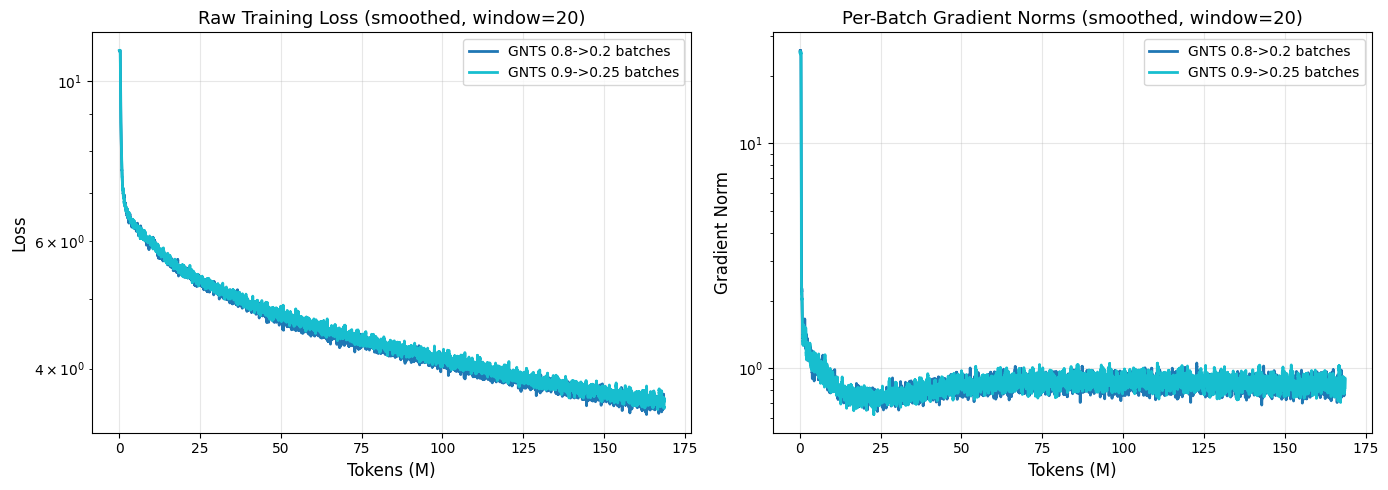

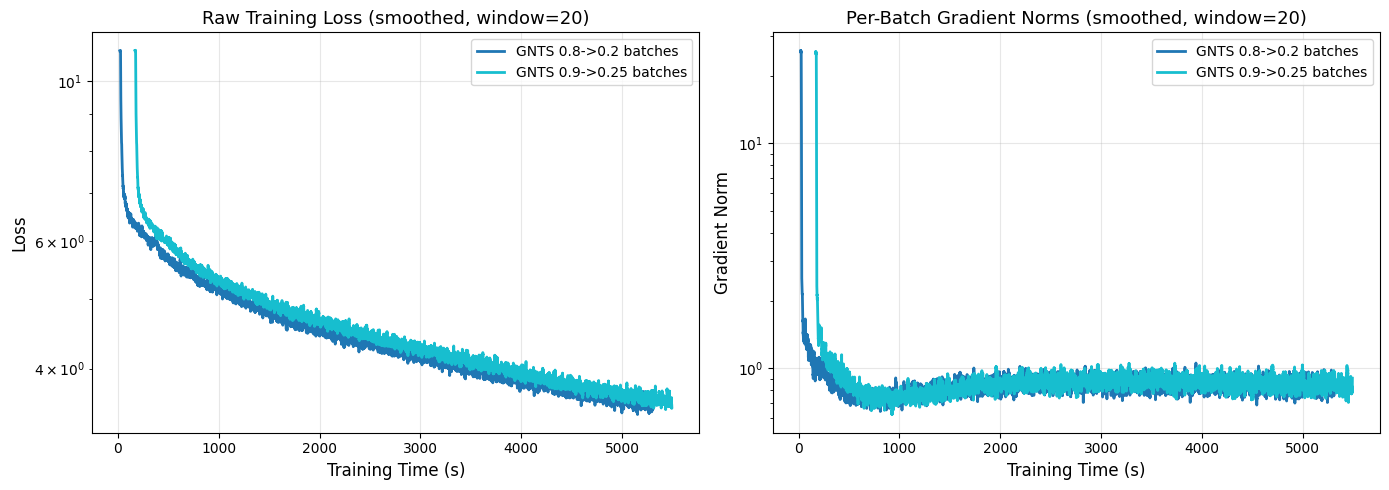

In [ ]:
# ============================================================================
# Configuration
# ============================================================================
EXPERIMENTS_TO_PLOT: List[str] = [
    "Control 64 batch size",
    "Scheduled 16->64 batch size",
    "Scheduled 16->64 batch size fast curve",
    "GNTS 1.0->0.3 batches",
    "GNTS 0.8->0.2 batches",
    "GNTS 0.5->0.1 batches",
    "GNTS 0.8->0.1 batches better shuffling",
    "GNTS 0.5->0.5 batches",
    "GNTS 0.4->0.4 batches",
    "GNTS 0.9->0.25 batches",
]

SMOOTH_WINDOW: int = 20
CONFIDENCE_LEVEL: float = 0.95  # Confidence level for intervals

# Compute z-score for confidence interval
Z_SCORE: float = stats.norm.ppf((1 + CONFIDENCE_LEVEL) / 2)

# Filter experiments to only those that exist
EXPERIMENTS_TO_PLOT = remove_experiments_that_do_not_exist(all_results, EXPERIMENTS_TO_PLOT)

# ============================================================================
# Raw Training Metrics Plotting
# ============================================================================

def smooth_data(data: np.ndarray, window: int) -> np.ndarray:
    """Apply simple moving average smoothing."""
    if window <= 1 or len(data) < window:
        return data
    cumsum = np.cumsum(np.insert(data, 0, 0))
    return (cumsum[window:] - cumsum[:-window]) / window

# Extract and organize data by experiment
experiment_data = {}
for exp_name in EXPERIMENTS_TO_PLOT:
    seeds = list(all_results[exp_name].keys())

    # Collect data across seeds
    all_tokens = []
    all_train_time = []
    all_loss = []
    all_norms = []

    for seed in seeds:
        metrics, metadata, model = all_results[exp_name][seed]
        raw = metrics["raw_train"]

        tokens = np.array(raw["tokens"]) / 1_000_000  # Convert to millions
        train_time = np.array(raw["train_time"])
        loss = np.array(raw["raw_loss"])
        norms = np.array(raw["raw_norms"])

        # Apply smoothing
        if len(loss) >= SMOOTH_WINDOW:
            loss = smooth_data(loss, SMOOTH_WINDOW)
            norms = smooth_data(norms, SMOOTH_WINDOW)
            # Adjust other arrays to match smoothed length
            tokens = tokens[SMOOTH_WINDOW-1:]
            train_time = train_time[SMOOTH_WINDOW-1:]

        all_tokens.append(tokens)
        all_train_time.append(train_time)
        all_loss.append(loss)
        all_norms.append(norms)

    experiment_data[exp_name] = {
        "tokens": all_tokens,
        "train_time": all_train_time,
        "loss": all_loss,
        "norms": all_norms,
        "n_seeds": len(seeds)
    }

# ============================================================================
# Plot: Loss and Grad Norms vs Tokens
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.tab10(np.linspace(0, 1, len(EXPERIMENTS_TO_PLOT)))

# Loss vs Tokens
ax = axes[0]
for idx, exp_name in enumerate(EXPERIMENTS_TO_PLOT):
    data = experiment_data[exp_name]

    if data["n_seeds"] == 1:
        # Single seed - just plot the line
        x = data["tokens"][0]
        y = data["loss"][0]
        ax.plot(x, y, label=exp_name, color=colors[idx], linewidth=2)
    else:
        # Multiple seeds - stack and compute mean + CI
        x = data["tokens"][0]  # All seeds have same x-values
        y_stacked = np.stack(data["loss"], axis=0)  # Shape: (n_seeds, n_points)

        y_mean = np.mean(y_stacked, axis=0)
        y_se = stats.sem(y_stacked, axis=0)
        y_ci = Z_SCORE * y_se

        ax.plot(x, y_mean, label=exp_name, color=colors[idx], linewidth=2)
        ax.fill_between(x, y_mean - y_ci, y_mean + y_ci,
                        color=colors[idx], alpha=0.2)

ax.set_xlabel("Tokens (M)", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_yscale("log")
ax.set_title(f"Raw Training Loss (smoothed, window={SMOOTH_WINDOW})", fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

# Grad Norms vs Tokens
ax = axes[1]
for idx, exp_name in enumerate(EXPERIMENTS_TO_PLOT):
    data = experiment_data[exp_name]

    if data["n_seeds"] == 1:
        x = data["tokens"][0]
        y = data["norms"][0]
        ax.plot(x, y, label=exp_name, color=colors[idx], linewidth=2)
    else:
        x = data["tokens"][0]
        y_stacked = np.stack(data["norms"], axis=0)

        y_mean = np.mean(y_stacked, axis=0)
        y_se = stats.sem(y_stacked, axis=0)
        y_ci = Z_SCORE * y_se

        ax.plot(x, y_mean, label=exp_name, color=colors[idx], linewidth=2)
        ax.fill_between(x, y_mean - y_ci, y_mean + y_ci,
                        color=colors[idx], alpha=0.2)

ax.set_xlabel("Tokens (M)", fontsize=12)
ax.set_ylabel("Gradient Norm", fontsize=12)
ax.set_yscale("log")
ax.set_title(f"Per-Batch Gradient Norms (smoothed, window={SMOOTH_WINDOW})", fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# Plot: Loss and Grad Norms vs Training Time
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss vs Training Time
ax = axes[0]
for idx, exp_name in enumerate(EXPERIMENTS_TO_PLOT):
    data = experiment_data[exp_name]

    if data["n_seeds"] == 1:
        x = data["train_time"][0]
        y = data["loss"][0]
        ax.plot(x, y, label=exp_name, color=colors[idx], linewidth=2)
    else:
        x = data["train_time"][0]
        y_stacked = np.stack(data["loss"], axis=0)

        y_mean = np.mean(y_stacked, axis=0)
        y_se = stats.sem(y_stacked, axis=0)
        y_ci = Z_SCORE * y_se

        ax.plot(x, y_mean, label=exp_name, color=colors[idx], linewidth=2)
        ax.fill_between(x, y_mean - y_ci, y_mean + y_ci,
                        color=colors[idx], alpha=0.2)

ax.set_xlabel("Training Time (s)", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_yscale("log")
ax.set_title(f"Raw Training Loss (smoothed, window={SMOOTH_WINDOW})", fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

# Grad Norms vs Training Time
ax = axes[1]
for idx, exp_name in enumerate(EXPERIMENTS_TO_PLOT):
    data = experiment_data[exp_name]

    if data["n_seeds"] == 1:
        x = data["train_time"][0]
        y = data["norms"][0]
        ax.plot(x, y, label=exp_name, color=colors[idx], linewidth=2)
    else:
        x = data["train_time"][0]
        y_stacked = np.stack(data["norms"], axis=0)

        y_mean = np.mean(y_stacked, axis=0)
        y_se = stats.sem(y_stacked, axis=0)
        y_ci = Z_SCORE * y_se

        ax.plot(x, y_mean, label=exp_name, color=colors[idx], linewidth=2)
        ax.fill_between(x, y_mean - y_ci, y_mean + y_ci,
                        color=colors[idx], alpha=0.2)

ax.set_xlabel("Training Time (s)", fontsize=12)
ax.set_ylabel("Gradient Norm", fontsize=12)
ax.set_yscale("log")
ax.set_title(f"Per-Batch Gradient Norms (smoothed, window={SMOOTH_WINDOW})", fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step Analysis

Analysis of various properties that occur every time the optimizers take a step.

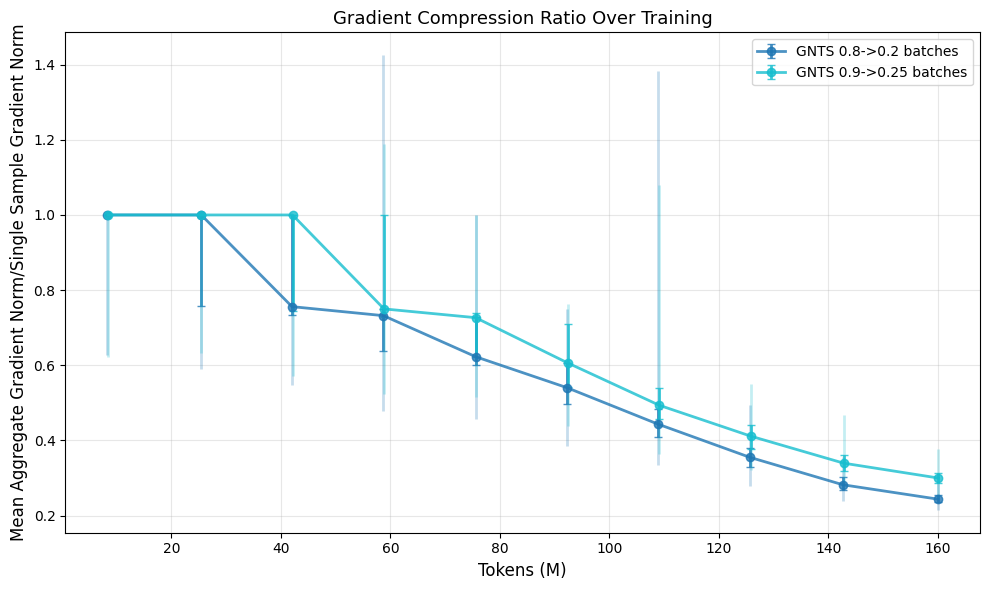

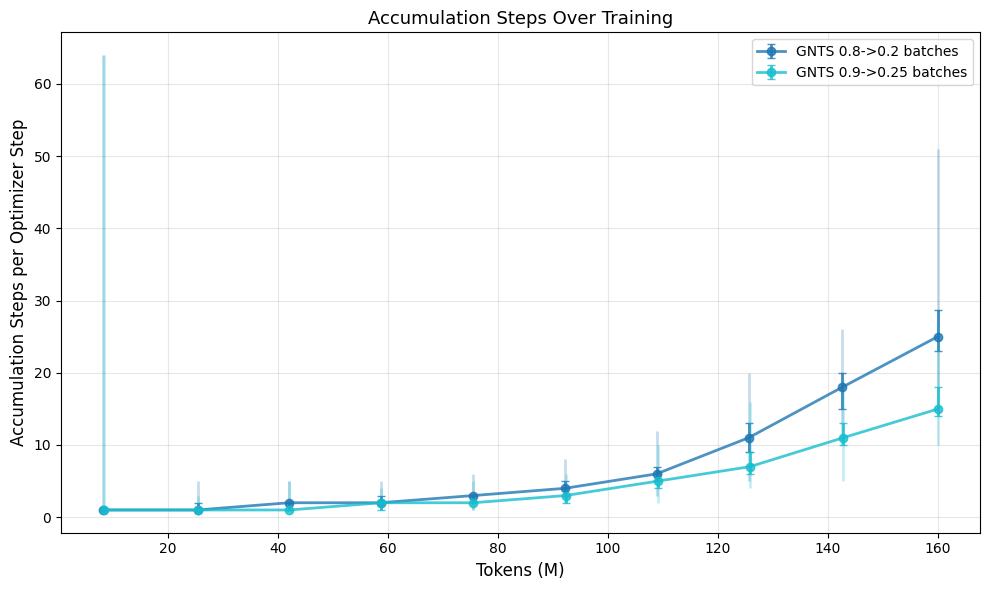

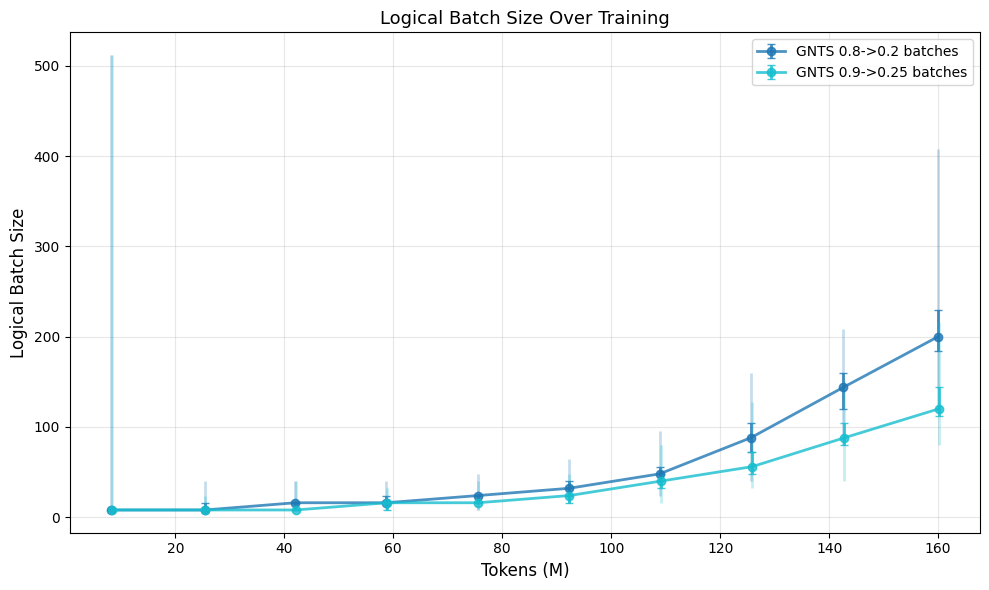

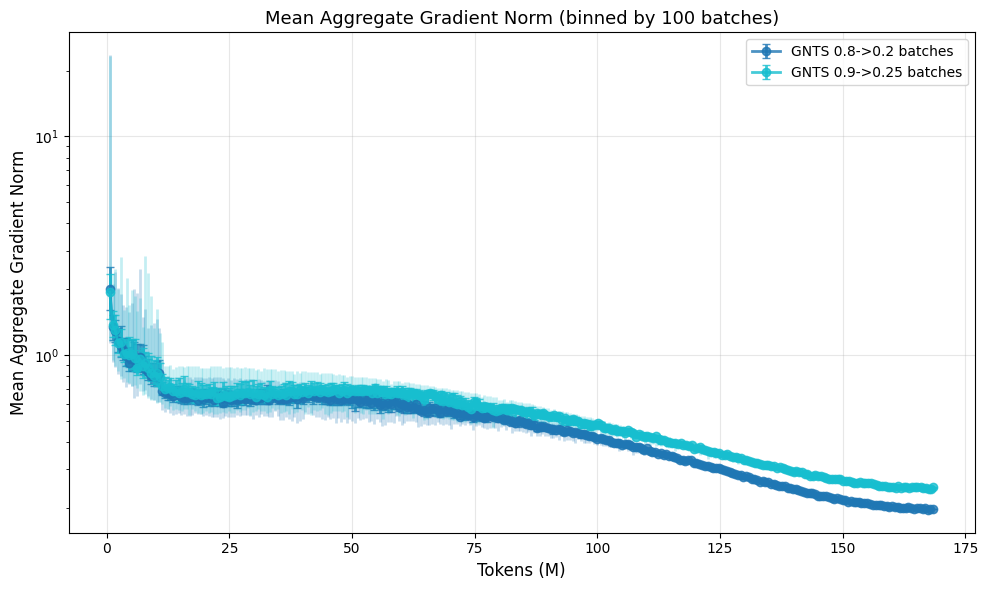

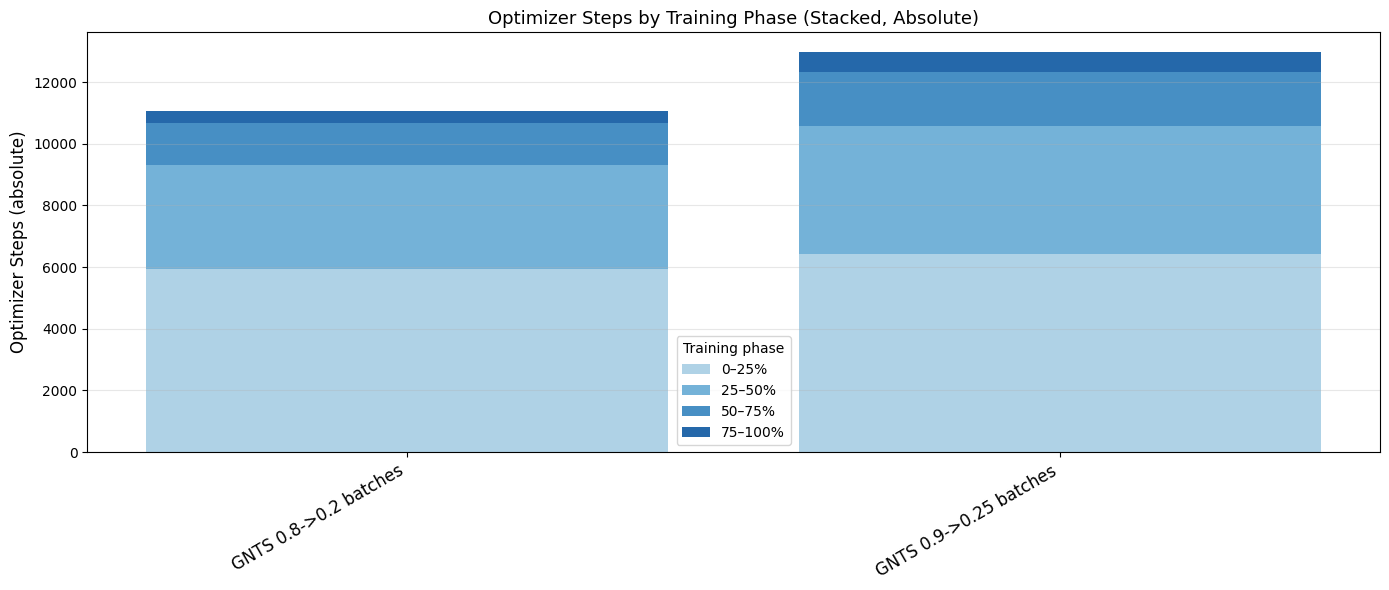

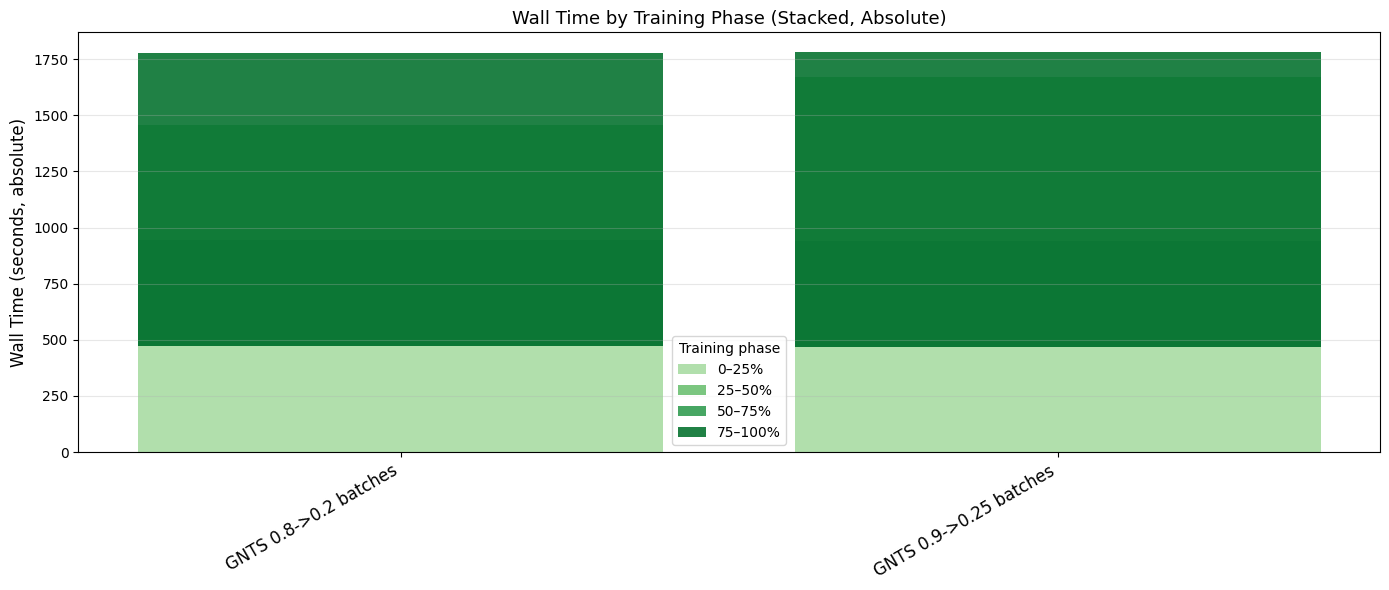

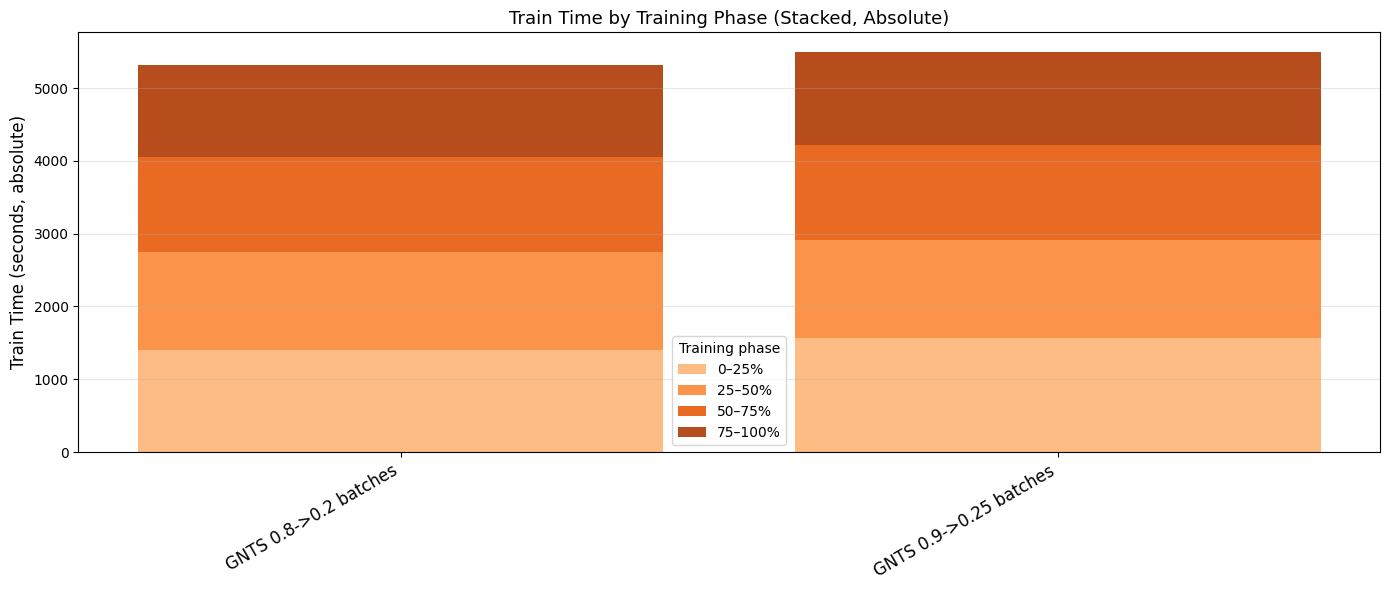

In [ ]:
# ============================================================================
# Configuration
# ============================================================================
EXPERIMENTS_TO_PLOT: List[str] = [
    "GNTS 1.0->0.3 batches",
    "GNTS 0.8->0.2 batches",
    "GNTS 0.5->0.1 batches",
    "GNTS 0.8->0.1 batches better shuffling",
    "GNTS 0.5->0.5 batches",
    "GNTS 0.4->0.4 batches",
    "GNTS 0.9->0.25 batches",
]  # Signal to noise not needed on control
EXPERIMENTS_FOR_ACCUM: List[str] = [
    "Control 64 batch size",
    "Scheduled 16->64 batch size",
    "Scheduled 16->64 batch size fast curve",
    "GNTS 1.0->0.3 batches",
    "GNTS 0.8->0.2 batches",
    "GNTS 0.5->0.1 batches",
    "GNTS 0.8->0.1 batches better shuffling",
    "GNTS 0.5->0.5 batches",
    "GNTS 0.4->0.4 batches",
    "GNTS 0.9->0.25 batches",
]  # For accum steps and logical batch size
EXPERIMENTS_FOR_AGGREGATE: List[str] = [
    "Control 64 batch size",
    "Scheduled 16->64 batch size",
    "Scheduled 16->64 batch size fast curve",
    "GNTS 1.0->0.3 batches",
    "GNTS 0.8->0.2 batches",
    "GNTS 0.5->0.1 batches",
    "GNTS 0.8->0.1 batches better shuffling",
    "GNTS 0.5->0.5 batches",
    "GNTS 0.4->0.4 batches",
    "GNTS 0.9->0.25 batches",
]  # For mean aggregate grad norm
EXPERIMENTS_FOR_COMPARISON: List[str] = [
    "Control 64 batch size",
    "Scheduled 16->64 batch size",
    "Scheduled 16->64 batch size fast curve",
    "GNTS 1.0->0.3 batches",
    "GNTS 0.8->0.2 batches",
    "GNTS 0.5->0.1 batches",
    "GNTS 0.8->0.1 batches better shuffling",
    "GNTS 0.5->0.5 batches",
    "GNTS 0.4->0.4 batches",
    "GNTS 0.9->0.25 batches",
]  # For optimizer steps and time analysis


N_CHUNKS: int = 10  # Number of chunks to divide training into for IQR analysis
BATCH_BIN_SIZE: int = 100  # Bin size for batch-based aggregation
CONFIDENCE_LEVEL: float = 0.95  # Confidence level for error bars
FIGSIZE: Tuple[int, int] = (10, 6)  # Figure size (width, height)
FONTSIZE_AXIS: int = 12  # Font size for axis labels
FONTSIZE_TITLE: int = 13  # Font size for titles
WHISKER_LINEWIDTH: int = 2  # Line width for min-max whiskers
N_MILESTONES: int = 4  # Number of milestones for optimizer steps analysis

# Compute z-score for confidence interval
Z_SCORE: float = stats.norm.ppf((1 + CONFIDENCE_LEVEL) / 2)

# Filter experiments to only those that exist
EXPERIMENTS_TO_PLOT = remove_experiments_that_do_not_exist(all_results, EXPERIMENTS_TO_PLOT)
EXPERIMENTS_FOR_ACCUM = remove_experiments_that_do_not_exist(all_results, EXPERIMENTS_FOR_ACCUM)
EXPERIMENTS_FOR_AGGREGATE = remove_experiments_that_do_not_exist(all_results, EXPERIMENTS_FOR_AGGREGATE)
EXPERIMENTS_FOR_COMPARISON = remove_experiments_that_do_not_exist(all_results, EXPERIMENTS_FOR_COMPARISON)

# ============================================================================
# Helper Functions
# ============================================================================

def compute_fixed_bin_stats(batch_nums: np.ndarray,
                           values: np.ndarray,
                           tokens: np.ndarray,
                           bin_size: int = 100) -> Tuple[List[float], List[float], List[float], List[float], List[float], List[float]]:
    """
    Divide data into fixed-size bins by batch_num and compute statistics.

    Args:
        batch_nums: Array of batch numbers
        values: Array of values to compute statistics on
        tokens: Array of token counts corresponding to batch_nums
        bin_size: Size of each bin in batch numbers

    Returns:
        mids: Mean token values for each bin
        medians, p25s, p75s, mins, maxs: Statistics for each bin
    """
    batch_min = int(batch_nums.min())
    batch_max = int(batch_nums.max())

    mids, medians, p25s, p75s, mins, maxs = [], [], [], [], [], []

    for bin_start in range(batch_min, batch_max + 1, bin_size):
        bin_end = bin_start + bin_size
        mask = (batch_nums >= bin_start) & (batch_nums < bin_end)

        chunk_values = values[mask]
        chunk_tokens = tokens[mask]

        mids.append(np.mean(chunk_tokens))
        medians.append(np.median(chunk_values))
        p25s.append(np.percentile(chunk_values, 25))
        p75s.append(np.percentile(chunk_values, 75))
        mins.append(chunk_values.min())
        maxs.append(chunk_values.max())

    return mids, medians, p25s, p75s, mins, maxs


def compute_iqr_chunks(batch_nums: np.ndarray,
                       values: np.ndarray,
                       tokens: np.ndarray,
                       n_chunks: int = 10) -> Tuple[List[float], List[float], List[float], List[float], List[float], List[float]]:
    """
    Divide data into chunks by batch_num and compute IQR statistics.

    Args:
        batch_nums: Array of batch numbers
        values: Array of values to compute statistics on
        tokens: Array of token counts corresponding to batch_nums
        n_chunks: Number of chunks to divide into

    Returns:
        mids: Mean token values for each chunk
        medians, p25s, p75s, mins, maxs: Statistics for each chunk
    """
    batch_min, batch_max = batch_nums.min(), batch_nums.max()
    edges = np.linspace(batch_min, batch_max, n_chunks + 1)

    mids, medians, p25s, p75s, mins, maxs = [], [], [], [], [], []

    for i in range(n_chunks):
        left, right = edges[i], edges[i + 1]
        mask = (batch_nums >= left) & (batch_nums < right if i < n_chunks - 1 else batch_nums <= right)

        chunk_values = values[mask]
        chunk_tokens = tokens[mask]

        # Use mean token value as x-coordinate for this chunk
        mids.append(np.mean(chunk_tokens))
        medians.append(np.median(chunk_values))
        p25s.append(np.percentile(chunk_values, 25))
        p75s.append(np.percentile(chunk_values, 75))
        mins.append(chunk_values.min())
        maxs.append(chunk_values.max())

    return mids, medians, p25s, p75s, mins, maxs


def aggregate_experiment_data(all_results: Dict[str, Dict[int, Tuple[Dict[str, Any], Dict[str, Any], Any]]],
                              exp_name: str,
                              metric_fn: Callable) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Aggregate data across all seeds for an experiment.

    Args:
        all_results: Full results dictionary
        exp_name: Experiment name
        metric_fn: Function that takes (metrics, metadata) and returns (batch_nums, values, tokens)

    Returns:
        Combined arrays of batch_nums, values, tokens across all seeds
    """
    all_batch_nums = []
    all_values = []
    all_tokens = []

    for seed in all_results[exp_name].keys():
        metrics, metadata, model = all_results[exp_name][seed]
        batch_nums, values, tokens = metric_fn(metrics, metadata)
        all_batch_nums.append(batch_nums)
        all_values.append(values)
        all_tokens.append(tokens)

    return (np.concatenate(all_batch_nums),
            np.concatenate(all_values),
            np.concatenate(all_tokens))


# ============================================================================
# Compression ratio (IQR Plot)
# ============================================================================
# Ratio of mean_aggregate_grad_norm to mean_single_sample_grad_norm
# Shows how much noise there must have been in gradient estimation

def extract_signal_to_noise(metrics: Dict[str, Any], metadata: Dict[str, Any]) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Extract signal-to-noise ratio from step_train metrics."""
    step = metrics["step_train"]
    batch_nums = np.array(step["batch_num"])
    tokens = np.array(step["tokens"]) / 1_000_000  # Convert to millions

    aggregate = np.array(step["mean_aggregate_grad_norm"])
    single_sample = np.array(step["mean_single_sample_grad_norm"])

    ratio = aggregate / single_sample

    return batch_nums, ratio, tokens


fig, ax = plt.subplots(1, 1, figsize=FIGSIZE)

colors = plt.cm.tab10(np.linspace(0, 1, len(EXPERIMENTS_TO_PLOT)))

for idx, exp_name in enumerate(EXPERIMENTS_TO_PLOT):
    batch_nums, ratios, tokens = aggregate_experiment_data(
        all_results, exp_name, extract_signal_to_noise
    )

    mids, medians, p25s, p75s, mins, maxs = compute_iqr_chunks(
        batch_nums, ratios, tokens, N_CHUNKS
    )

    ax.errorbar(mids, medians,
                yerr=[np.array(medians) - np.array(p25s),
                      np.array(p75s) - np.array(medians)],
                fmt='o-', capsize=3, alpha=0.8, linewidth=2,
                label=exp_name, color=colors[idx])

    for x, lo, hi in zip(mids, mins, maxs):
        ax.vlines(x, lo, hi, alpha=0.25, linewidth=WHISKER_LINEWIDTH, color=colors[idx])

ax.set_xlabel("Tokens (M)", fontsize=FONTSIZE_AXIS)
ax.set_ylabel("Mean Aggregate Gradient Norm/Single Sample Gradient Norm", fontsize=FONTSIZE_AXIS)
ax.set_title("Gradient Compression Ratio Over Training", fontsize=FONTSIZE_TITLE)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================================
# Accumulation Steps (IQR Plot)
# ============================================================================

def extract_accum_steps(metrics: Dict[str, Any], metadata: Dict[str, Any]) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Extract accumulation steps from step_train metrics."""
    step = metrics["step_train"]
    return (np.array(step["batch_num"]),
            np.array(step["accum_steps"]),
            np.array(step["tokens"]) / 1_000_000)  # Convert to millions


fig, ax = plt.subplots(1, 1, figsize=FIGSIZE)

colors = plt.cm.tab10(np.linspace(0, 1, len(EXPERIMENTS_FOR_ACCUM)))

for idx, exp_name in enumerate(EXPERIMENTS_FOR_ACCUM):
    batch_nums, accum, tokens = aggregate_experiment_data(
        all_results, exp_name, extract_accum_steps
    )

    mids, medians, p25s, p75s, mins, maxs = compute_iqr_chunks(
        batch_nums, accum, tokens, N_CHUNKS
    )

    ax.errorbar(mids, medians,
                yerr=[np.array(medians) - np.array(p25s),
                      np.array(p75s) - np.array(medians)],
                fmt='o-', capsize=3, alpha=0.8, linewidth=2,
                label=exp_name, color=colors[idx])

    for x, lo, hi in zip(mids, mins, maxs):
        ax.vlines(x, lo, hi, alpha=0.25, linewidth=WHISKER_LINEWIDTH, color=colors[idx])

ax.set_xlabel("Tokens (M)", fontsize=FONTSIZE_AXIS)
ax.set_ylabel("Accumulation Steps per Optimizer Step", fontsize=FONTSIZE_AXIS)
ax.set_title("Accumulation Steps Over Training", fontsize=FONTSIZE_TITLE)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================================
# Logical Batch Size (IQR Plot)
# ============================================================================

def extract_logical_batch_size(metrics: Dict[str, Any], metadata: Dict[str, Any]) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Extract logical batch size (accum_steps * batch_size) from step_train metrics."""
    step = metrics["step_train"]
    batch_size = metadata["dataset_config"]["batch_size"]

    batch_nums = np.array(step["batch_num"])
    accum = np.array(step["accum_steps"])
    tokens = np.array(step["tokens"]) / 1_000_000  # Convert to millions

    logical_batch = accum * batch_size

    return batch_nums, logical_batch, tokens


fig, ax = plt.subplots(1, 1, figsize=FIGSIZE)

colors = plt.cm.tab10(np.linspace(0, 1, len(EXPERIMENTS_FOR_ACCUM)))

for idx, exp_name in enumerate(EXPERIMENTS_FOR_ACCUM):
    batch_nums, logical_batch, tokens = aggregate_experiment_data(
        all_results, exp_name, extract_logical_batch_size
    )

    mids, medians, p25s, p75s, mins, maxs = compute_iqr_chunks(
        batch_nums, logical_batch, tokens, N_CHUNKS
    )

    ax.errorbar(mids, medians,
                yerr=[np.array(medians) - np.array(p25s),
                      np.array(p75s) - np.array(medians)],
                fmt='o-', capsize=3, alpha=0.8, linewidth=2,
                label=exp_name, color=colors[idx])

    for x, lo, hi in zip(mids, mins, maxs):
        ax.vlines(x, lo, hi, alpha=0.25, linewidth=WHISKER_LINEWIDTH, color=colors[idx])

ax.set_xlabel("Tokens (M)", fontsize=FONTSIZE_AXIS)
ax.set_ylabel("Logical Batch Size", fontsize=FONTSIZE_AXIS)
ax.set_title("Logical Batch Size Over Training", fontsize=FONTSIZE_TITLE)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================================
# Mean Aggregate Gradient Norm (Binned Plot)
# ============================================================================

def extract_mean_aggregate_norm(metrics: Dict[str, Any], metadata: Dict[str, Any]) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Extract mean aggregate gradient norm from step_train metrics."""
    step = metrics["step_train"]
    return (np.array(step["batch_num"]),
            np.array(step["mean_aggregate_grad_norm"]),
            np.array(step["tokens"]) / 1_000_000)  # Convert to millions


fig, ax = plt.subplots(1, 1, figsize=FIGSIZE)

colors = plt.cm.tab10(np.linspace(0, 1, len(EXPERIMENTS_FOR_AGGREGATE)))

for idx, exp_name in enumerate(EXPERIMENTS_FOR_AGGREGATE):
    batch_nums, norms, tokens = aggregate_experiment_data(
        all_results, exp_name, extract_mean_aggregate_norm
    )

    mids, medians, p25s, p75s, mins, maxs = compute_fixed_bin_stats(
        batch_nums, norms, tokens, BATCH_BIN_SIZE
    )

    ax.errorbar(mids, medians,
                yerr=[np.array(medians) - np.array(p25s),
                      np.array(p75s) - np.array(medians)],
                fmt='o-', capsize=3, alpha=0.8, linewidth=2,
                label=exp_name, color=colors[idx])

    for x, lo, hi in zip(mids, mins, maxs):
        ax.vlines(x, lo, hi, alpha=0.25, linewidth=WHISKER_LINEWIDTH, color=colors[idx])

ax.set_xlabel("Tokens (M)", fontsize=FONTSIZE_AXIS)
ax.set_ylabel("Mean Aggregate Gradient Norm", fontsize=FONTSIZE_AXIS)
ax.set_yscale("log")
ax.set_title(f"Mean Aggregate Gradient Norm (binned by {BATCH_BIN_SIZE} batches)", fontsize=FONTSIZE_TITLE)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================================
# Optimizer Steps Analysis (Stacked/Cumulative Bar Graphs at Milestones)
# ============================================================================

def extract_values_at_milestones(tokens_m: np.ndarray,
                                 values: np.ndarray,
                                 milestones_m: np.ndarray) -> List[float]:
    """
    For each milestone in token-space (millions), take the value at the last index <= milestone.
    """
    out: List[float] = []
    for milestone in milestones_m:
        idx = np.searchsorted(tokens_m, milestone, side="right") - 1
        idx = max(0, min(int(idx), len(values) - 1))
        out.append(values[idx])
    return out


def mean_over_seeds(per_seed_rows: List[List[float]]) -> np.ndarray:
    """
    Mean over seeds for each milestone.
    """
    return np.array(per_seed_rows).mean(axis=0)


def milestone_deltas(milestone_values: np.ndarray) -> np.ndarray:
    """
    Convert cumulative milestone values [m1, m2, m3, m4] into phase deltas
    [m1-0, m2-m1, m3-m2, m4-m3].
    """
    return np.diff(milestone_values, prepend=0.0)


# ----------------------------------------------------------------------------
# Compute milestones from step_train tokens (millions)
# ----------------------------------------------------------------------------

max_tokens = 0.0
for exp_name in EXPERIMENTS_FOR_COMPARISON:
    for seed in all_results[exp_name].keys():
        metrics, metadata, model = all_results[exp_name][seed]
        tokens = np.array(metrics["step_train"]["tokens"]) / 1_000_000
        max_tokens = max(max_tokens, float(tokens.max()))

milestones = np.linspace(0.0, max_tokens, N_MILESTONES + 1)[1:]  # [1/4, 2/4, 3/4, 4/4]
milestone_labels = [f"{int(i*100/N_MILESTONES)}–{int((i+1)*100/N_MILESTONES)}%" for i in range(N_MILESTONES)]


# ----------------------------------------------------------------------------
# Compute mean cumulative optimizer steps at milestones, then deltas
# ----------------------------------------------------------------------------

optimizer_phase_deltas = []

for exp_name in EXPERIMENTS_FOR_COMPARISON:
    per_seed_rows: List[List[float]] = []

    for seed in all_results[exp_name].keys():
        metrics, metadata, model = all_results[exp_name][seed]
        step = metrics["step_train"]

        tokens_m = np.array(step["tokens"]) / 1_000_000
        optimizer_steps = np.array(step["optimizer_step"])

        per_seed_rows.append(extract_values_at_milestones(tokens_m, optimizer_steps, milestones))

    mean_milestones = mean_over_seeds(per_seed_rows)
    optimizer_phase_deltas.append(milestone_deltas(mean_milestones))

optimizer_phase_deltas = np.array(optimizer_phase_deltas)  # shape: (n_exps, n_milestones)


# ----------------------------------------------------------------------------
# Plot stacked bars (absolute Y)
# ----------------------------------------------------------------------------

fig, ax = plt.subplots(1, 1, figsize=(14, 6))

x = np.arange(len(EXPERIMENTS_FOR_COMPARISON))
bottom = np.zeros(len(EXPERIMENTS_FOR_COMPARISON))

phase_colors = plt.cm.Blues(np.linspace(0.35, 0.85, N_MILESTONES))

for phase_idx in range(N_MILESTONES):
    heights = optimizer_phase_deltas[:, phase_idx]
    ax.bar(x, heights, bottom=bottom, color=phase_colors[phase_idx], label=milestone_labels[phase_idx], alpha=0.9)
    bottom = bottom + heights

ax.set_xticks(x)
ax.set_xticklabels(EXPERIMENTS_FOR_COMPARISON, rotation=30, ha="right", fontsize=FONTSIZE_AXIS)
ax.set_ylabel("Optimizer Steps (absolute)", fontsize=FONTSIZE_AXIS)
ax.set_title("Optimizer Steps by Training Phase (Stacked, Absolute)", fontsize=FONTSIZE_TITLE)
ax.legend(title="Training phase")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


# ============================================================================
# Time Analysis (Stacked/Cumulative Bar Graphs at Milestones)
# ============================================================================

# ----------------------------------------------------------------------------
# Compute milestones from raw_train tokens (millions)
# ----------------------------------------------------------------------------

max_tokens = 0.0
for exp_name in EXPERIMENTS_FOR_COMPARISON:
    for seed in all_results[exp_name].keys():
        metrics, metadata, model = all_results[exp_name][seed]
        raw = metrics["raw_train"]
        tokens = np.array(raw["tokens"]) / 1_000_000
        max_tokens = max(max_tokens, float(tokens.max()))

milestones = np.linspace(0.0, max_tokens, N_MILESTONES + 1)[1:]
milestone_labels = [f"{int(i*100/N_MILESTONES)}–{int((i+1)*100/N_MILESTONES)}%" for i in range(N_MILESTONES)]


# ----------------------------------------------------------------------------
# Compute mean cumulative wall/train time at milestones, then deltas
# ----------------------------------------------------------------------------

wall_phase_deltas = []
train_phase_deltas = []

for exp_name in EXPERIMENTS_FOR_COMPARISON:
    wall_per_seed: List[List[float]] = []
    train_per_seed: List[List[float]] = []

    for seed in all_results[exp_name].keys():
        metrics, metadata, model = all_results[exp_name][seed]
        raw = metrics["raw_train"]

        tokens_m = np.array(raw["tokens"]) / 1_000_000
        wall_time = np.array(raw["wall_time"])
        train_time = np.array(raw["train_time"])

        wall_per_seed.append(extract_values_at_milestones(tokens_m, wall_time, milestones))
        train_per_seed.append(extract_values_at_milestones(tokens_m, train_time, milestones))

    wall_mean_milestones = mean_over_seeds(wall_per_seed)
    train_mean_milestones = mean_over_seeds(train_per_seed)

    wall_phase_deltas.append(milestone_deltas(wall_mean_milestones))
    train_phase_deltas.append(milestone_deltas(train_mean_milestones))

wall_phase_deltas = np.array(wall_phase_deltas)
train_phase_deltas = np.array(train_phase_deltas)


# ----------------------------------------------------------------------------
# Plot: Wall time stacked bars (absolute Y)
# ----------------------------------------------------------------------------

fig, ax = plt.subplots(1, 1, figsize=(14, 6))

x = np.arange(len(EXPERIMENTS_FOR_COMPARISON))
bottom = np.zeros(len(EXPERIMENTS_FOR_COMPARISON))
phase_colors = plt.cm.Greens(np.linspace(0.35, 0.85, N_MILESTONES))

for phase_idx in range(N_MILESTONES):
    heights = wall_phase_deltas[:, phase_idx]
    ax.bar(x, heights, bottom=bottom, color=phase_colors[phase_idx], label=milestone_labels[phase_idx], alpha=0.9)
    bottom = bottom + heights

ax.set_xticks(x)
ax.set_xticklabels(EXPERIMENTS_FOR_COMPARISON, rotation=30, ha="right", fontsize=FONTSIZE_AXIS)
ax.set_ylabel("Wall Time (seconds, absolute)", fontsize=FONTSIZE_AXIS)
ax.set_title("Wall Time by Training Phase (Stacked, Absolute)", fontsize=FONTSIZE_TITLE)
ax.legend(title="Training phase")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------------
# Plot: Train time stacked bars (absolute Y)
# ----------------------------------------------------------------------------

fig, ax = plt.subplots(1, 1, figsize=(14, 6))

x = np.arange(len(EXPERIMENTS_FOR_COMPARISON))
bottom = np.zeros(len(EXPERIMENTS_FOR_COMPARISON))
phase_colors = plt.cm.Oranges(np.linspace(0.35, 0.85, N_MILESTONES))

for phase_idx in range(N_MILESTONES):
    heights = train_phase_deltas[:, phase_idx]
    ax.bar(x, heights, bottom=bottom, color=phase_colors[phase_idx], label=milestone_labels[phase_idx], alpha=0.9)
    bottom = bottom + heights

ax.set_xticks(x)
ax.set_xticklabels(EXPERIMENTS_FOR_COMPARISON, rotation=30, ha="right", fontsize=FONTSIZE_AXIS)
ax.set_ylabel("Train Time (seconds, absolute)", fontsize=FONTSIZE_AXIS)
ax.set_title("Train Time by Training Phase (Stacked, Absolute)", fontsize=FONTSIZE_TITLE)
ax.legend(title="Training phase")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()
